# Solucionario Examen Final - Física Computacional

Este notebook contiene la resolución de los ejercicios propuestos en el examen final.


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math

# Configuración de gráficos
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('ggplot')


# 1: Análisis Estadístico de la Caminata Aleatoria en 2D

**Enunciado:**
Considere una partícula que realiza una caminata aleatoria de $N$ pasos en el plano $xy$. Cada paso $i$ está definido por un desplazamiento $(\Delta x_i, \Delta y_i)$.

*   **a)** A partir de la definición del cuadrado de la distancia neta $R^2 = (\sum \Delta x_i)^2 + (\sum \Delta y_i)^2$, demuestre que, para un número grande de pasos aleatorios e independientes, el valor cuadrático medio de la distancia total se simplifica a $R_{rms}^2 \simeq N r_{rms}^2$. Explique por qué los términos de productos cruzados ($2\Delta x_i \Delta x_j$) tienden a cero en el promedio.
*   **b)** Basándose en las gráficas de simulación presentadas en clase desde 10 hasta 1,000,000 de pasos (enviadas como archivo adjunto en su momento) describa cualitativamente cómo cambia la densidad de la trayectoria y el desplazamiento neto a medida que $N$ aumenta.
*   **c)** ¿Cómo se relaciona esto con la escala de los ejes?

---
## Solución

### a) Demostración del Valor Cuadrático Medio

Partimos de la definición del desplazamiento neto cuadrático. Sea $\vec{R}$ el vector desplazamiento total después de $N$ pasos, donde cada paso es $\vec{r}_i = (\Delta x_i, \Delta y_i)$.
$$ \vec{R} = \sum_{i=1}^{N} \vec{r}_i $$

El cuadrado de la distancia neta es el producto punto consigo mismo:
$$ R^2 = \vec{R} \cdot \vec{R} = \left( \sum_{i=1}^{N} \vec{r}_i \right) \cdot \left( \sum_{j=1}^{N} \vec{r}_j \right) $$
$$ R^2 = \sum_{i=1}^{N} r_i^2 + \sum_{i \neq j} \vec{r}_i \cdot \vec{r}_j $$

Tomando el valor esperado (promedio) sobre un gran número de caminatas:
$$ \langle R^2 \rangle = \sum_{i=1}^{N} \langle r_i^2 \rangle + \sum_{i \neq j} \langle \vec{r}_i \cdot \vec{r}_j \rangle $$

Si asumimos que los pasos tienen la misma longitud cuadrática media $\langle r_i^2 \rangle = r_{rms}^2$, el primer término es simplemente $N r_{rms}^2$.

**Sobre los términos cruzados:**
El segundo término contiene productos de la forma $\vec{r}_i \cdot \vec{r}_j = r_i r_j \cos \theta_{ij}$, donde $\theta_{ij}$ es el ángulo entre los pasos $i$ y $j$. En una caminata aleatoria isotrópica e independiente, la dirección de cada paso es aleatoria y no correlacionada con los otros. Por lo tanto, el coseno del ángulo puede ser positivo o negativo con igual probabilidad, haciendo que el promedio tienda a cero:
$$ \langle \vec{r}_i \cdot \vec{r}_j \rangle = 0 \quad \text{para } i \neq j $$

Finalmente obtenemos:
$$ \langle R^2 \rangle \simeq N r_{rms}^2 $$

### b) Densidad de la Trayectoria y Desplazamiento Neto

Al aumentar $N$:
1.  **Densidad de la trayectoria:** La partícula visita una región del espacio cada vez más densa localmente, pero el área total explorada crece más lentamente que el número de pasos. Visualmente, la trayectoria se ve más "apretada" o "rellena" en el gráfico, pareciendo una nube sólida en escalas grandes debido a la naturaleza fractal del movimiento browniano a límite continuo.
2.  **Desplazamiento neto:** Aunque la distancia total recorrida es $N \times l$ (donde $l$ es la longitud del paso), el desplazamiento neto desde el origen crece solo como $\sqrt{N}$. Esto significa que la partícula se aleja del origen mucho más lentamente de lo que se mueve.

### c) Relación con la Escala de los Ejes

Dado que el desplazamiento típico escala con $\sqrt{N}$, si graficamos caminatas de muy diferentes $N$ (ej. 10 vs 1,000,000), debemos ajustar la escala de los ejes proporcionalmente a $\sqrt{N}$ para ver estructuras similares. Si mantenemos la escala fija, la caminata de $N$ grande se saldrá de la gráfica o la de $N$ pequeño se verá como un punto. Si normalizamos por $\sqrt{N}$, las distribuciones estadísticas de la posición final serían comparables.



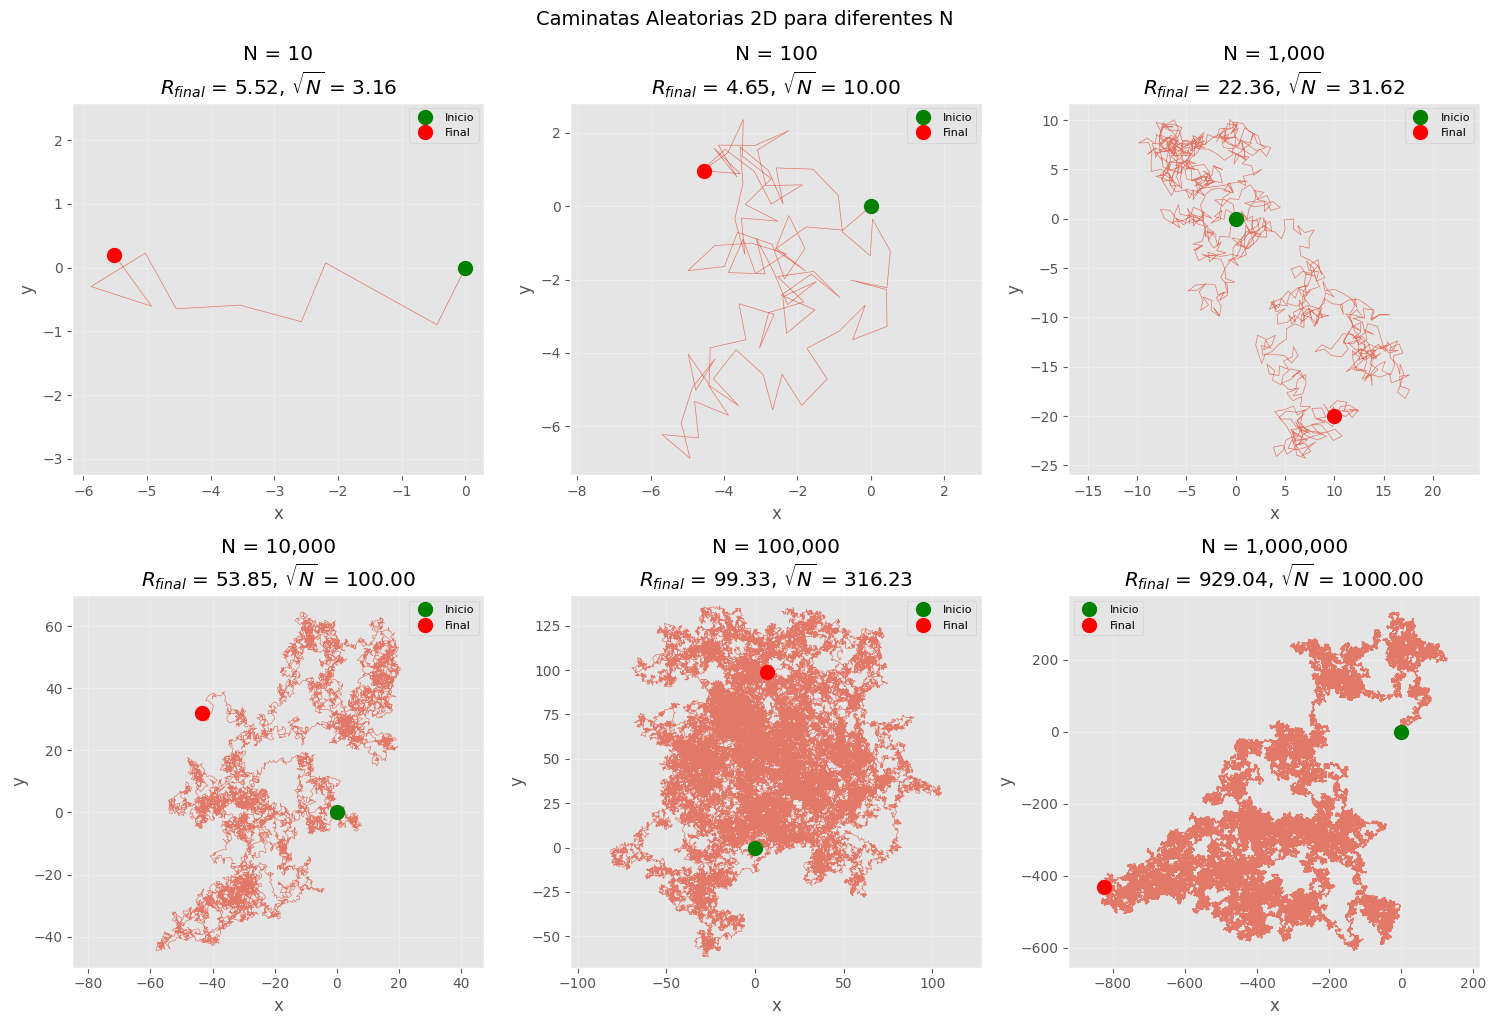


VERIFICACIÓN ESTADÍSTICA: <R²> ≈ N·r_rms²
N =    10 | R_rms simulado =     3.20 | √N teórico =     3.16
N =    50 | R_rms simulado =     7.08 | √N teórico =     7.07
N =   100 | R_rms simulado =    10.16 | √N teórico =    10.00
N =   500 | R_rms simulado =    22.54 | √N teórico =    22.36
N =  1000 | R_rms simulado =    31.42 | √N teórico =    31.62
N =  5000 | R_rms simulado =    71.19 | √N teórico =    70.71


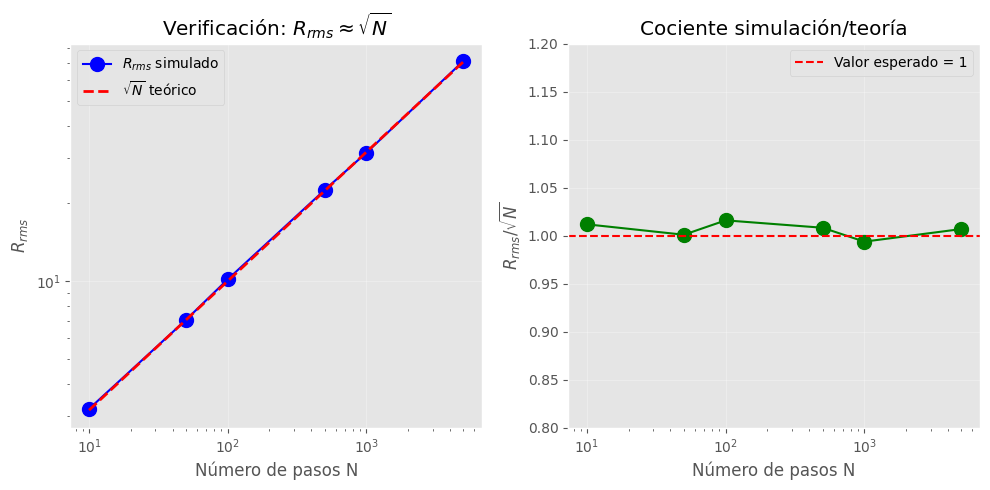

In [30]:
# ============================================================
# IMPLEMENTACIÓN COMPUTACIONAL: Caminata Aleatoria 2D
# ============================================================

def caminata_aleatoria_2d(n_pasos, paso=1):
    """Simula una caminata aleatoria en 2D."""
    angulos = np.random.uniform(0, 2*np.pi, n_pasos)
    dx = paso * np.cos(angulos)
    dy = paso * np.sin(angulos)
    x = np.cumsum(dx)
    y = np.cumsum(dy)
    return np.insert(x, 0, 0), np.insert(y, 0, 0)

# Simulación para diferentes valores de N
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
N_values = [10, 100, 1000, 10000, 100000, 1000000]

for ax, N in zip(axes.flatten(), N_values):
    x, y = caminata_aleatoria_2d(N)
    ax.plot(x, y, lw=0.5, alpha=0.7)
    ax.plot(0, 0, 'go', markersize=10, label='Inicio')
    ax.plot(x[-1], y[-1], 'ro', markersize=10, label='Final')
    R_final = np.sqrt(x[-1]**2 + y[-1]**2)
    ax.set_title(f'N = {N:,}\n$R_{{final}}$ = {R_final:.2f}, $\\sqrt{{N}}$ = {np.sqrt(N):.2f}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.axis('equal')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Caminatas Aleatorias 2D para diferentes N', fontsize=14, y=1.02)
plt.show()

# Verificación estadística: R_rms vs sqrt(N)
print("\n" + "="*60)
print("VERIFICACIÓN ESTADÍSTICA: <R²> ≈ N·r_rms²")
print("="*60)

n_simulaciones = 500
N_test = [10, 50, 100, 500, 1000, 5000]
R_rms_valores = []
R_rms_teorico = []

for N in N_test:
    R2_suma = 0
    for _ in range(n_simulaciones):
        x, y = caminata_aleatoria_2d(N)
        R2_suma += x[-1]**2 + y[-1]**2
    R_rms = np.sqrt(R2_suma / n_simulaciones)
    R_rms_valores.append(R_rms)
    R_rms_teorico.append(np.sqrt(N))  # Para paso unitario r_rms = 1
    print(f"N = {N:5d} | R_rms simulado = {R_rms:8.2f} | √N teórico = {np.sqrt(N):8.2f}")

# Gráfica de verificación
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.loglog(N_test, R_rms_valores, 'bo-', label='$R_{rms}$ simulado', markersize=10)
plt.loglog(N_test, R_rms_teorico, 'r--', label='$\\sqrt{N}$ teórico', linewidth=2)
plt.xlabel('Número de pasos N')
plt.ylabel('$R_{rms}$')
plt.title('Verificación: $R_{rms} \\approx \\sqrt{N}$')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
ratio = np.array(R_rms_valores) / np.array(R_rms_teorico)
plt.semilogx(N_test, ratio, 'go-', markersize=10)
plt.axhline(y=1, color='r', linestyle='--', label='Valor esperado = 1')
plt.xlabel('Número de pasos N')
plt.ylabel('$R_{rms} / \\sqrt{N}$')
plt.title('Cociente simulación/teoría')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.8, 1.2)

plt.tight_layout()
plt.show()

# 2: Modelado Estocástico y Analítico del Decaimiento Radiactivo

**Enunciado:**
*   **a)** Utilizando la ley de decaimiento radiactivo $\frac{dN(t)}{dt} = -\lambda N(t)$, derive la expresión para el número de átomos en función del tiempo $N(t) = N(0)e^{-\lambda t}$. Defina la relación entre la constante de decaimiento $\lambda$ y la vida media $\tau$.
*   **b)** Observe la gráfica de decaimiento para el par $^{211}\text{Ra} \to ^{211}\text{Ac}$. Explique por qué la curva del núcleo hijo (Actinio) comienza en cero, alcanza un máximo y luego decae, mientras que el núcleo padre decae monótonamente.
*   **c)** ¿Qué ventaja ofrece una simulación de Monte Carlo frente a la solución analítica cuando el número de átomos es muy pequeño (p. ej., $N = 10$)?

---
## Solución

### a) Derivación

Partimos de la ecuación diferencial:
$$ \frac{dN}{dt} = -\lambda N $$
Separamos variables e integramos desde $t=0$ hasta $t$:
$$ \int_{N_0}^{N(t)} \frac{dN'}{N'} = -\lambda \int_{0}^{t} dt' $$
$$ \ln(N(t)) - \ln(N_0) = -\lambda t $$
$$ \ln\left(\frac{N(t)}{N_0}\right) = -\lambda t $$
Exponenciando ambos lados:
$$ N(t) = N(0)e^{-\lambda t} $$

**Relación con la vida media ($\tau$):**
La vida media es el tiempo promedio que un átomo sobrevive antes de decaer. Se define como $\tau = 1/\lambda$. También se suele usar el tiempo de vida media $t_{1/2} = \ln(2)/\lambda$.

### b) Curvas Padre e Hijo

*   **Núcleo Padre (Ra):** Decae exponencialmente porque solo se consume; no se produce. Por eso su curva es monótona decreciente.
*   **Núcleo Hijo (Ac):** Comienza en cero (asumiendo que no hay Actinio inicial). Al principio, la tasa de producción (proporcional al número de núcleos padre) es alta y supera a su propia tasa de decaimiento (proporcional a su propia cantidad, que es baja), por lo que su población crece. Eventualmente, al disminuir los padres, la producción baja y el decaimiento del hijo domina, haciendo que alcance un máximo y luego disminuya asintóticamente a cero.

### c) Ventaja de Monte Carlo para $N$ pequeño

La solución analítica $N(t) = N_0 e^{-\lambda t}$ es un modelo continuo y determinista válido en el límite termodinámico ($N \to \infty$). Describe el **promedio** del comportamiento.
Cuando $N$ es pequeño (ej. 10), las fluctuaciones estocásticas son enormes y significativas. Los átomos decaen en tiempos discretos y aleatorios, no de forma continua. Monte Carlo captura naturalmente esta naturaleza discreta y estocástica, mostrando los "saltos" reales de la población y la variabilidad entre diferentes experimentos, algo que la curva analítica suave no puede representar.



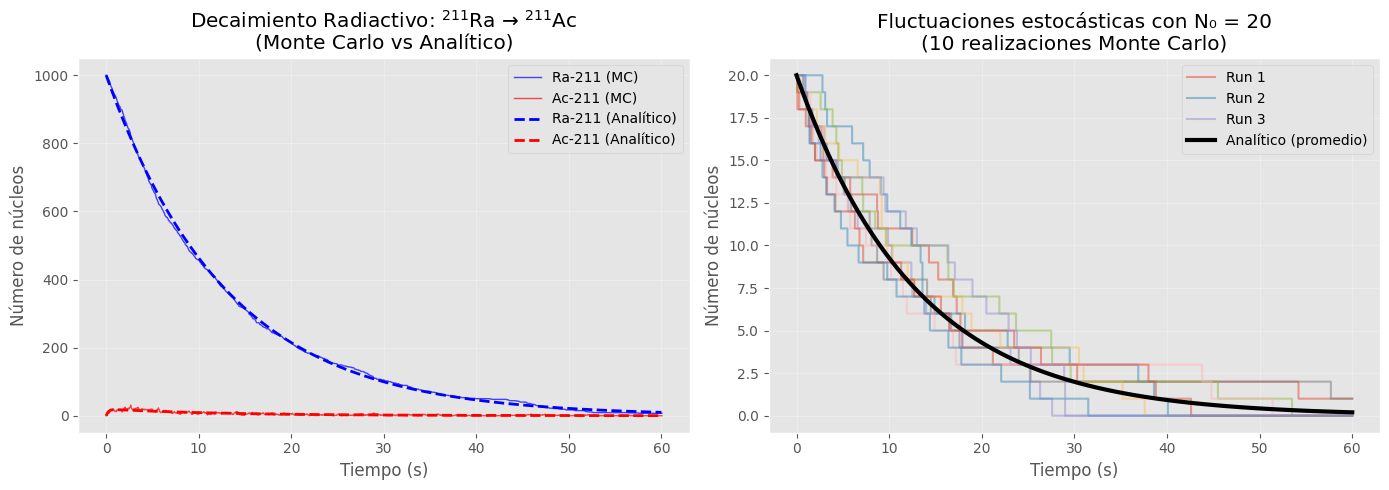


OBSERVACIONES:
• El núcleo padre (Ra-211) decae exponencialmente de forma monótona.
• El núcleo hijo (Ac-211) crece inicialmente, alcanza un máximo,
  y luego decae cuando la producción disminuye.
• Con N pequeño, las fluctuaciones estocásticas son muy evidentes.
• La solución analítica representa el promedio de muchas realizaciones.


In [31]:
# ============================================================
# IMPLEMENTACIÓN COMPUTACIONAL: Decaimiento Radiactivo
# ============================================================

def decaimiento_analitico(N0, lambda_decay, t):
    """Solución analítica del decaimiento radiactivo."""
    return N0 * np.exp(-lambda_decay * t)

def decaimiento_montecarlo(N0, lambda_decay, dt, t_max):
    """Simulación Monte Carlo del decaimiento radiactivo."""
    t = 0
    N = N0
    tiempos = [0]
    poblacion = [N0]
    
    while t < t_max and N > 0:
        # Probabilidad de decaimiento en intervalo dt
        p_decay = lambda_decay * dt
        # Número de núcleos que decaen
        decays = np.sum(np.random.random(N) < p_decay)
        N -= decays
        t += dt
        tiempos.append(t)
        poblacion.append(N)
    
    return np.array(tiempos), np.array(poblacion)

def decaimiento_cadena(N_padre_0, lambda_padre, lambda_hijo, t_max, dt=0.01):
    """Simula cadena de decaimiento Padre -> Hijo (Monte Carlo)."""
    tiempos = [0]
    N_padre = [N_padre_0]
    N_hijo = [0]
    
    n_padre = N_padre_0
    n_hijo = 0
    t = 0
    
    while t < t_max:
        # Decaimiento del padre
        if n_padre > 0:
            p_decay_padre = lambda_padre * dt
            decays_padre = np.sum(np.random.random(n_padre) < p_decay_padre)
        else:
            decays_padre = 0
        
        # Decaimiento del hijo
        if n_hijo > 0:
            p_decay_hijo = lambda_hijo * dt
            decays_hijo = np.sum(np.random.random(n_hijo) < p_decay_hijo)
        else:
            decays_hijo = 0
        
        n_padre -= decays_padre
        n_hijo += decays_padre - decays_hijo
        t += dt
        
        tiempos.append(t)
        N_padre.append(n_padre)
        N_hijo.append(n_hijo)
    
    return np.array(tiempos), np.array(N_padre), np.array(N_hijo)

# Parámetros para Ra-211 -> Ac-211
# Vida media Ra-211 ≈ 13s, Ac-211 ≈ 0.25s (aproximación)
tau_padre = 13.0  # segundos
tau_hijo = 0.25   # segundos
lambda_padre = 1/tau_padre
lambda_hijo = 1/tau_hijo

N0 = 1000
t_max = 60  # segundos

# Solución analítica para la cadena
t_analitico = np.linspace(0, t_max, 500)
N_padre_analitico = N0 * np.exp(-lambda_padre * t_analitico)
# Solución del hijo (Bateman equation para dos etapas)
N_hijo_analitico = N0 * lambda_padre / (lambda_hijo - lambda_padre) * \
                   (np.exp(-lambda_padre * t_analitico) - np.exp(-lambda_hijo * t_analitico))

# Simulación Monte Carlo
np.random.seed(42)
t_mc, N_padre_mc, N_hijo_mc = decaimiento_cadena(N0, lambda_padre, lambda_hijo, t_max, dt=0.05)

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: Comparación MC vs Analítico
ax1 = axes[0]
ax1.plot(t_mc, N_padre_mc, 'b-', alpha=0.7, label='Ra-211 (MC)', linewidth=1)
ax1.plot(t_mc, N_hijo_mc, 'r-', alpha=0.7, label='Ac-211 (MC)', linewidth=1)
ax1.plot(t_analitico, N_padre_analitico, 'b--', label='Ra-211 (Analítico)', linewidth=2)
ax1.plot(t_analitico, N_hijo_analitico, 'r--', label='Ac-211 (Analítico)', linewidth=2)
ax1.set_xlabel('Tiempo (s)')
ax1.set_ylabel('Número de núcleos')
ax1.set_title('Decaimiento Radiactivo: $^{211}$Ra → $^{211}$Ac\n(Monte Carlo vs Analítico)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel derecho: Múltiples realizaciones para N pequeño
ax2 = axes[1]
N0_small = 20
for i in range(10):
    t_s, N_padre_s, _ = decaimiento_cadena(N0_small, lambda_padre, 0, t_max, dt=0.1)
    ax2.step(t_s, N_padre_s, alpha=0.5, where='post', label=f'Run {i+1}' if i < 3 else None)

t_analitico_small = np.linspace(0, t_max, 100)
N_analitico_small = N0_small * np.exp(-lambda_padre * t_analitico_small)
ax2.plot(t_analitico_small, N_analitico_small, 'k-', linewidth=3, label='Analítico (promedio)')
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Número de núcleos')
ax2.set_title(f'Fluctuaciones estocásticas con N₀ = {N0_small}\n(10 realizaciones Monte Carlo)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("OBSERVACIONES:")
print("="*60)
print("• El núcleo padre (Ra-211) decae exponencialmente de forma monótona.")
print("• El núcleo hijo (Ac-211) crece inicialmente, alcanza un máximo,")
print("  y luego decae cuando la producción disminuye.")
print("• Con N pequeño, las fluctuaciones estocásticas son muy evidentes.")
print("• La solución analítica representa el promedio de muchas realizaciones.")

# 3: Procesos Estocásticos

**Enunciado:**
Explica cómo ambos fenómenos anteriores (caminata aleatoria y decaimiento radioactivo) son ejemplos de procesos estocásticos en física.

---
## Solución

Un proceso estocástico es aquel cuya evolución temporal está gobernada por leyes probabilísticas en lugar de deterministas.

1.  **Caminata Aleatoria:** La posición futura de la partícula no se puede predecir con certeza a partir de su posición actual. Solo se conoce la **probabilidad** de dar un paso en cierta dirección. Cada paso es un evento aleatorio.
2.  **Decaimiento Radiactivo:** No se puede predecir cuándo decaerá un núcleo específico. Solo existe una probabilidad de decaimiento por unidad de tiempo ($\lambda$). El proceso es intrínsecamente aleatorio a nivel cuántico.

En ambos casos, aunque el comportamiento individual es impredecible, el comportamiento colectivo de un gran número de eventos o partículas sigue leyes estadísticas bien definidas (difusión, ley exponencial), lo cual es la esencia de la física estadística.



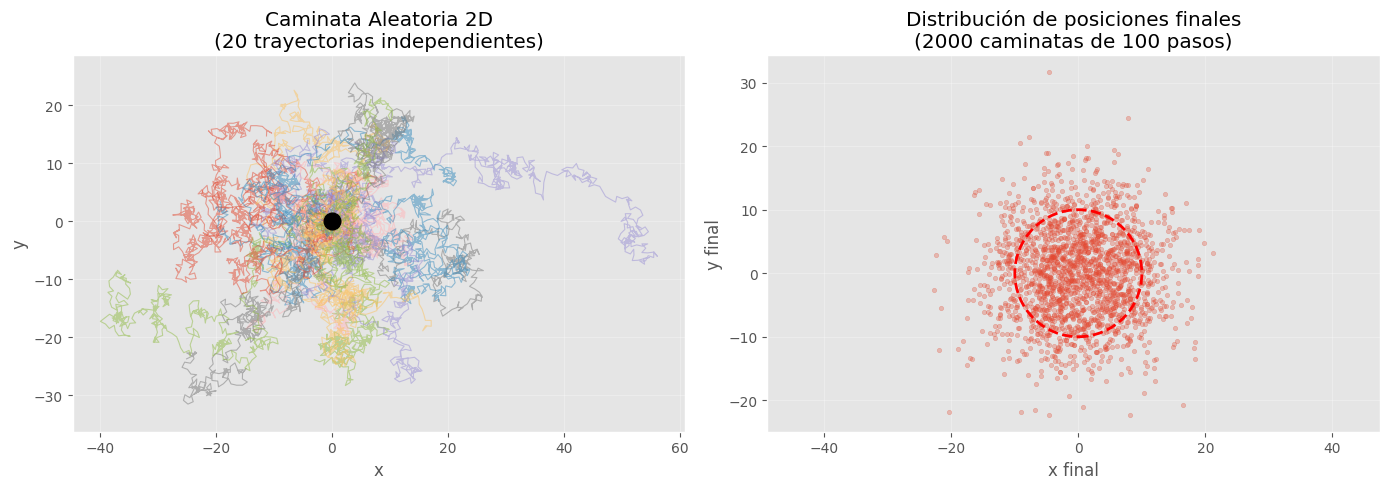


CONEXIÓN ENTRE PROCESOS ESTOCÁSTICOS

SIMILITUDES:
• Ambos procesos son gobernados por probabilidades, no determinismo.
• El comportamiento individual es impredecible.
• El comportamiento colectivo sigue leyes estadísticas bien definidas.

DIFERENCIAS:
• Caminata: La partícula persiste, su posición cambia aleatoriamente.
• Decaimiento: Los núcleos desaparecen, el proceso es irreversible.

MATEMÁTICAMENTE:
• Caminata → Ecuación de difusión: ∂P/∂t = D∇²P
• Decaimiento → Ecuación de decaimiento: dN/dt = -λN



In [32]:
# ============================================================
# IMPLEMENTACIÓN COMPUTACIONAL: Visualización Procesos Estocásticos
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: Caminata aleatoria - múltiples trayectorias
ax1 = axes[0]
np.random.seed(123)
for i in range(20):
    x, y = caminata_aleatoria_2d(500)
    ax1.plot(x, y, alpha=0.5, linewidth=0.8)
ax1.plot(0, 0, 'ko', markersize=12, zorder=5)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Caminata Aleatoria 2D\n(20 trayectorias independientes)')
ax1.axis('equal')
ax1.grid(True, alpha=0.3)

# Panel derecho: Histograma de posiciones finales
ax2 = axes[1]
n_walks = 2000
x_final = []
y_final = []
for _ in range(n_walks):
    x, y = caminata_aleatoria_2d(100)
    x_final.append(x[-1])
    y_final.append(y[-1])

ax2.scatter(x_final, y_final, alpha=0.3, s=10)
circle = plt.Circle((0, 0), np.sqrt(100), fill=False, color='red', linewidth=2, linestyle='--')
ax2.add_patch(circle)
ax2.set_xlabel('x final')
ax2.set_ylabel('y final')
ax2.set_title(f'Distribución de posiciones finales\n({n_walks} caminatas de 100 pasos)')
ax2.axis('equal')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Conexión estadística
print("\n" + "="*70)
print("CONEXIÓN ENTRE PROCESOS ESTOCÁSTICOS")
print("="*70)
print("""
SIMILITUDES:
• Ambos procesos son gobernados por probabilidades, no determinismo.
• El comportamiento individual es impredecible.
• El comportamiento colectivo sigue leyes estadísticas bien definidas.

DIFERENCIAS:
• Caminata: La partícula persiste, su posición cambia aleatoriamente.
• Decaimiento: Los núcleos desaparecen, el proceso es irreversible.

MATEMÁTICAMENTE:
• Caminata → Ecuación de difusión: ∂P/∂t = D∇²P
• Decaimiento → Ecuación de decaimiento: dN/dt = -λN
""")

# 4: Estimación Estocástica de Constantes Geométricas

**Enunciado:**
Utilizando el método de Monte Carlo para aproximar el valor de $\pi$, se inscribe un círculo de radio $R$ dentro de un cuadrado de lado $2R$. Si se generan $N$ puntos aleatorios con una distribución uniforme dentro del cuadrado y $N_c$ es el número de puntos que caen dentro del círculo, demuestre, basándose en la relación de áreas presentada en las diapositivas, que la aproximación de $\pi$ viene dada por:
$$ \pi \approx 4 \times \frac{N_c}{N} $$
Explique además qué sucede con la precisión de esta aproximación a medida que el número de muestras $N$ aumenta de 10 a 1,000,000, considerando los resultados visuales de las simulaciones.

---
## Solución

### Demostración

El área del cuadrado de lado $2R$ es:
$$ A_{cuad} = (2R)^2 = 4R^2 $$
El área del círculo inscrito de radio $R$ es:
$$ A_{circ} = \pi R^2 $$

La probabilidad $P$ de que un punto lanzado uniformemente al azar caiga dentro del círculo es igual a la razón de las áreas:
$$ P = \frac{A_{circ}}{A_{cuad}} = \frac{\pi R^2}{4R^2} = \frac{\pi}{4} $$

Si lanzamos $N$ puntos, el número esperado de aciertos $N_c$ es $N \times P$. Por lo tanto, podemos estimar $P$ como la frecuencia observada $N_c / N$:
$$ \frac{N_c}{N} \approx \frac{\pi}{4} $$
Despejando $\pi$ obtenemos:
$$ \pi \approx 4 \times \frac{N_c}{N} $$

### Precisión vs $N$

A medida que $N$ aumenta, la precisión mejora. El error en métodos de Monte Carlo típicamente decae proporcionalmente a $1/\sqrt{N}$.
*   **$N=10$:** La estimación es muy pobre y fluctuante. Visualmente los puntos apenas cubren el área.
*   **$N=1,000,000$:** La frecuencia $N_c/N$ converge al valor teórico de probabilidad. La estimación de $\pi$ tendrá muchas más cifras significativas correctas. Visualmente, los puntos llenan densamente el espacio, definiendo claramente la frontera del círculo.



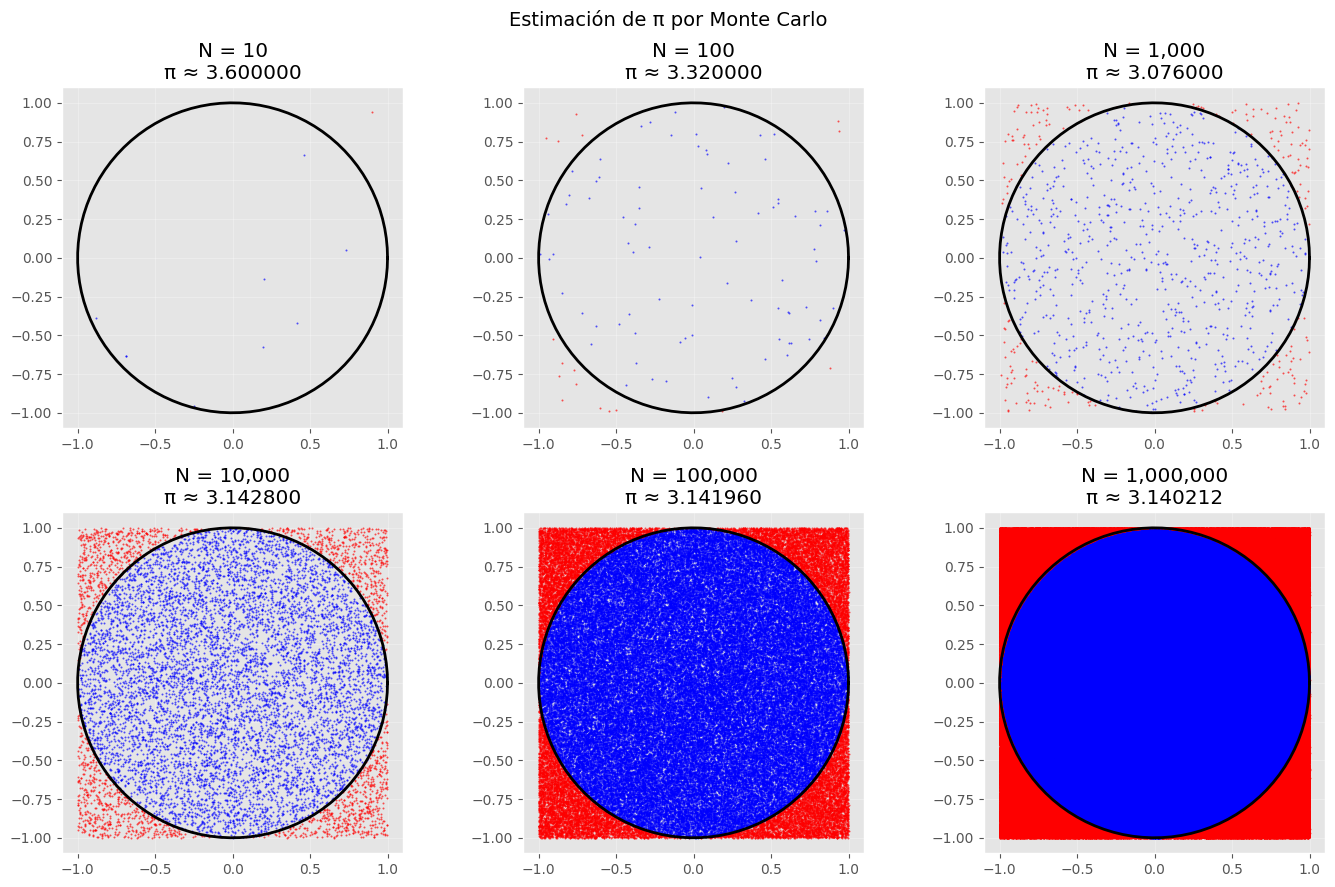


ANÁLISIS DE CONVERGENCIA


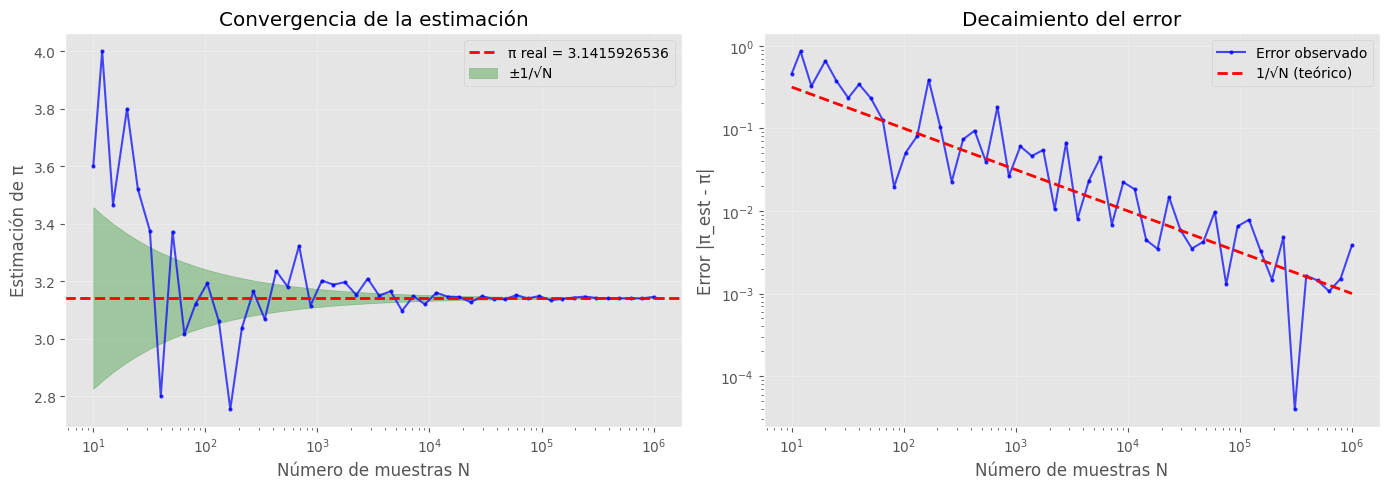


--------------------------------------------------
         N |      π estimado |           Error
--------------------------------------------------
        10 |    3.6000000000 |    0.4584073464
       100 |    3.2800000000 |    0.1384073464
     1,000 |    3.0960000000 |    0.0455926536
    10,000 |    3.1348000000 |    0.0067926536
   100,000 |    3.1441200000 |    0.0025273464
 1,000,000 |    3.1398920000 |    0.0017006536
--------------------------------------------------
    π real |    3.1415926536 |


In [33]:
# ============================================================
# IMPLEMENTACIÓN COMPUTACIONAL: Estimación de π con Monte Carlo
# ============================================================

def estimar_pi_visual(N, ax=None):
    """Estima π y opcionalmente visualiza los puntos."""
    x = np.random.uniform(-1, 1, N)
    y = np.random.uniform(-1, 1, N)
    dentro = x**2 + y**2 <= 1
    pi_est = 4 * np.sum(dentro) / N
    
    if ax is not None:
        ax.scatter(x[dentro], y[dentro], c='blue', s=1, alpha=0.5, label='Dentro')
        ax.scatter(x[~dentro], y[~dentro], c='red', s=1, alpha=0.5, label='Fuera')
        theta = np.linspace(0, 2*np.pi, 100)
        ax.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=2)
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        ax.set_aspect('equal')
        ax.set_title(f'N = {N:,}\nπ ≈ {pi_est:.6f}')
        ax.grid(True, alpha=0.3)
    
    return pi_est

# Visualización para diferentes N
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
N_values = [10, 100, 1000, 10000, 100000, 1000000]

np.random.seed(42)
for ax, N in zip(axes.flatten(), N_values):
    estimar_pi_visual(N, ax)

plt.suptitle('Estimación de π por Monte Carlo', fontsize=14)
plt.tight_layout()
plt.show()

# Análisis de convergencia
print("\n" + "="*60)
print("ANÁLISIS DE CONVERGENCIA")
print("="*60)

N_range = np.logspace(1, 6, 50).astype(int)
pi_estimates = []
errors = []

np.random.seed(123)
for N in N_range:
    pi_est = estimar_pi_visual(N)
    pi_estimates.append(pi_est)
    errors.append(abs(pi_est - np.pi))

# Gráfica de convergencia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.semilogx(N_range, pi_estimates, 'b.-', alpha=0.7, markersize=4)
ax1.axhline(y=np.pi, color='r', linestyle='--', linewidth=2, label=f'π real = {np.pi:.10f}')
ax1.fill_between(N_range, np.pi - 1/np.sqrt(N_range), np.pi + 1/np.sqrt(N_range), 
                  alpha=0.3, color='green', label='±1/√N')
ax1.set_xlabel('Número de muestras N')
ax1.set_ylabel('Estimación de π')
ax1.set_title('Convergencia de la estimación')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.loglog(N_range, errors, 'b.-', alpha=0.7, markersize=4, label='Error observado')
ax2.loglog(N_range, 1/np.sqrt(N_range), 'r--', linewidth=2, label='1/√N (teórico)')
ax2.set_xlabel('Número de muestras N')
ax2.set_ylabel('Error |π_est - π|')
ax2.set_title('Decaimiento del error')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla resumen
print("\n" + "-"*50)
print(f"{'N':>10} | {'π estimado':>15} | {'Error':>15}")
print("-"*50)
for N in [10, 100, 1000, 10000, 100000, 1000000]:
    np.random.seed(42)
    pi_est = estimar_pi_visual(N)
    print(f"{N:>10,} | {pi_est:>15.10f} | {abs(pi_est - np.pi):>15.10f}")
print("-"*50)
print(f"{'π real':>10} | {np.pi:>15.10f} |")

# 5: Integración Numérica de Monte Carlo

**Enunciado:**
Para evaluar la integral definida $F = \int_{a}^{b} f(x) dx$ mediante el método de Monte Carlo, se utiliza el valor promedio de la función evaluada en puntos aleatorios.

*   **a)** Escriba la expresión matemática para el estimador de la integral $\langle F \rangle$ basada en una muestra de $N$ puntos $X_i$ distribuidos uniformemente en el intervalo $[a, b]$.
*   **b)** Si se desea implementar este método en Python para la función $f(x) = -x^3 + 6x^2 - x + 17$, mencione qué método del módulo random sería el más adecuado para generar los valores de $X_i$ como números de punto flotante entre los límites $[0,10]$.

---
## Solución

### a) Estimador de la Integral

El valor promedio de la función en el intervalo $[a, b]$ se aproxima por el promedio muestral:
$$ \langle f \rangle \approx \frac{1}{N} \sum_{i=1}^{N} f(X_i) $$
La integral es el promedio multiplicado por el ancho del intervalo $(b-a)$:
$$ F \approx (b-a) \frac{1}{N} \sum_{i=1}^{N} f(X_i) $$

### b) Implementación en Python

Para generar números de punto flotante con distribución uniforme en el intervalo $[0, 10]$, la función adecuada del módulo `random` es:

`random.uniform(0, 10)`

Esta función devuelve un `float` $x$ tal que $0 \le x \le 10$.



Integral exacta: -380.0


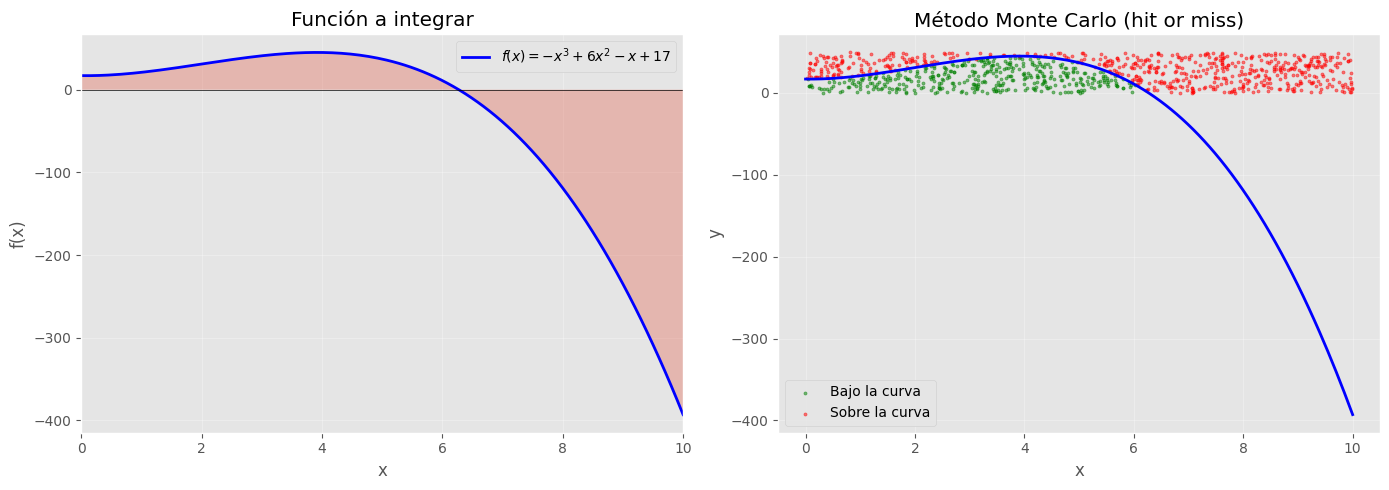


MÉTODO DEL VALOR MEDIO: F ≈ (b-a) × <f(x)>


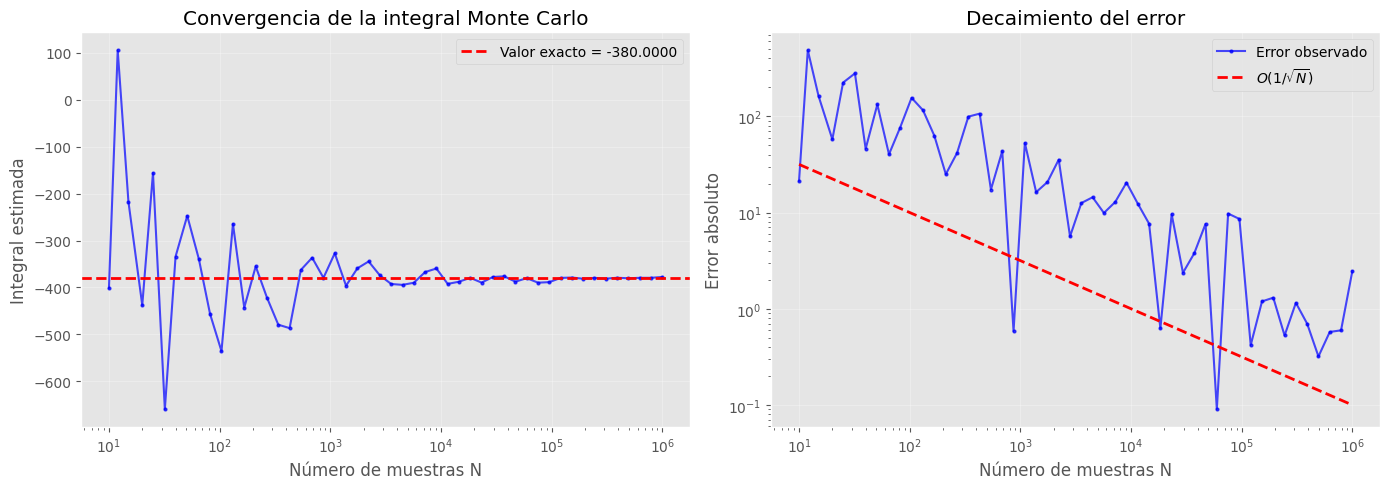


------------------------------------------------------------
         N |     Integral MC |           Error |    Error %
------------------------------------------------------------
        10 |     -468.473852 |       88.473852 |  -23.2826%
       100 |     -329.144040 |       50.855960 |  -13.3831%
     1,000 |     -367.319850 |       12.680150 |   -3.3369%
    10,000 |     -356.890151 |       23.109849 |   -6.0815%
   100,000 |     -375.953835 |        4.046165 |   -1.0648%
 1,000,000 |     -380.759654 |        0.759654 |   -0.1999%
------------------------------------------------------------
    Exacto |     -380.000000 |


In [34]:
# ============================================================
# IMPLEMENTACIÓN COMPUTACIONAL: Integración Monte Carlo
# ============================================================

def f(x):
    """Función a integrar: f(x) = -x³ + 6x² - x + 17"""
    return -x**3 + 6*x**2 - x + 17

def integral_montecarlo(func, a, b, N):
    """Calcula la integral de func en [a,b] usando N puntos aleatorios."""
    x = np.random.uniform(a, b, N)
    return (b - a) * np.mean(func(x))

# Parámetros
a, b = 0, 10

# Valor exacto de la integral (calculado analíticamente)
# ∫(-x³ + 6x² - x + 17)dx = -x⁴/4 + 2x³ - x²/2 + 17x
def F_primitiva(x):
    return -x**4/4 + 2*x**3 - x**2/2 + 17*x

integral_exacta = F_primitiva(b) - F_primitiva(a)
print(f"Integral exacta: {integral_exacta}")

# Visualización de la función y el área
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: La función y el área
ax1 = axes[0]
x_plot = np.linspace(a, b, 200)
y_plot = f(x_plot)
ax1.plot(x_plot, y_plot, 'b-', linewidth=2, label='$f(x) = -x^3 + 6x^2 - x + 17$')
ax1.fill_between(x_plot, y_plot, alpha=0.3)
ax1.axhline(y=0, color='k', linewidth=0.5)
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.set_title('Función a integrar')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(a, b)

# Panel derecho: Método Monte Carlo visual
ax2 = axes[1]
N_visual = 1000
x_mc = np.random.uniform(a, b, N_visual)
y_mc = f(x_mc)
f_max = np.max(y_plot) * 1.1
y_random = np.random.uniform(0, f_max, N_visual)
dentro = y_random <= y_mc

ax2.scatter(x_mc[dentro], y_random[dentro], c='green', s=5, alpha=0.5, label='Bajo la curva')
ax2.scatter(x_mc[~dentro], y_random[~dentro], c='red', s=5, alpha=0.5, label='Sobre la curva')
ax2.plot(x_plot, y_plot, 'b-', linewidth=2)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Método Monte Carlo (hit or miss)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de convergencia
print("\n" + "="*60)
print("MÉTODO DEL VALOR MEDIO: F ≈ (b-a) × <f(x)>")
print("="*60)

N_range = np.logspace(1, 6, 50).astype(int)
integrales = []
errores = []

np.random.seed(456)
for N in N_range:
    I_mc = integral_montecarlo(f, a, b, N)
    integrales.append(I_mc)
    errores.append(abs(I_mc - integral_exacta))

# Gráfica de convergencia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.semilogx(N_range, integrales, 'b.-', alpha=0.7, markersize=4)
ax1.axhline(y=integral_exacta, color='r', linestyle='--', linewidth=2, 
            label=f'Valor exacto = {integral_exacta:.4f}')
ax1.set_xlabel('Número de muestras N')
ax1.set_ylabel('Integral estimada')
ax1.set_title('Convergencia de la integral Monte Carlo')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.loglog(N_range, errores, 'b.-', alpha=0.7, markersize=4, label='Error observado')
ax2.loglog(N_range, 100/np.sqrt(N_range), 'r--', linewidth=2, label='$O(1/\\sqrt{N})$')
ax2.set_xlabel('Número de muestras N')
ax2.set_ylabel('Error absoluto')
ax2.set_title('Decaimiento del error')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla de resultados
print("\n" + "-"*60)
print(f"{'N':>10} | {'Integral MC':>15} | {'Error':>15} | {'Error %':>10}")
print("-"*60)
for N in [10, 100, 1000, 10000, 100000, 1000000]:
    np.random.seed(42)
    I_mc = integral_montecarlo(f, a, b, N)
    err = abs(I_mc - integral_exacta)
    err_pct = 100 * err / integral_exacta
    print(f"{N:>10,} | {I_mc:>15.6f} | {err:>15.6f} | {err_pct:>9.4f}%")
print("-"*60)
print(f"{'Exacto':>10} | {integral_exacta:>15.6f} |")

# 6: Sobre el Método de Monte Carlo en Física

**Enunciado:**
Considere una magnitud física que puede expresarse como un valor esperado (por ejemplo, energía promedio, área efectiva o probabilidad de transición).

*   **a)** Explique cómo el método de Monte Carlo puede emplearse para estimar dicha magnitud.
*   **b)** Describa un ejemplo concreto de aplicación del método Monte Carlo en física.
*   **c)** Mencione una ventaja y una limitación del método Monte Carlo en este tipo de aplicaciones.

---
## Solución

### a) Estimación de valores esperados

El método de Monte Carlo estima un valor esperado $E[X]$ mediante el promedio aritmético de una gran cantidad de muestras aleatorias independientes generadas a partir de la distribución de probabilidad que gobierna el sistema.
Si la magnitud es $A = \int A(x) p(x) dx$, generamos estados $x_i$ con probabilidad $p(x)$ y calculamos:
$$ A \approx \frac{1}{N} \sum_{i=1}^{N} A(x_i) $$

### b) Ejemplo concreto: Modelo de Ising / Mecánica Estadística

Se utiliza Monte Carlo (específicamente algoritmos como Metrópolis) para simular sistemas de espines (Modelo de Ising). Se generan configuraciones aleatorias de espines aceptadas con probabilidad de Boltzmann. Promediando la magnetización o la energía de estas configuraciones, se obtienen las propiedades termodinámicas del material a una temperatura $T$.

### c) Ventaja y Limitación

*   **Ventaja:** Permite resolver integrales de muy alta dimensión (muchos grados de libertad) donde los métodos de cuadratura tradicionales fallan.
*   **Limitación:** La convergencia es lenta. El error disminuye como $1/\sqrt{N}$, lo que significa que para ganar un dígito extra de precisión se requiere aumentar el número de muestras por un factor de 100.



Simulando modelo de Ising 1D...


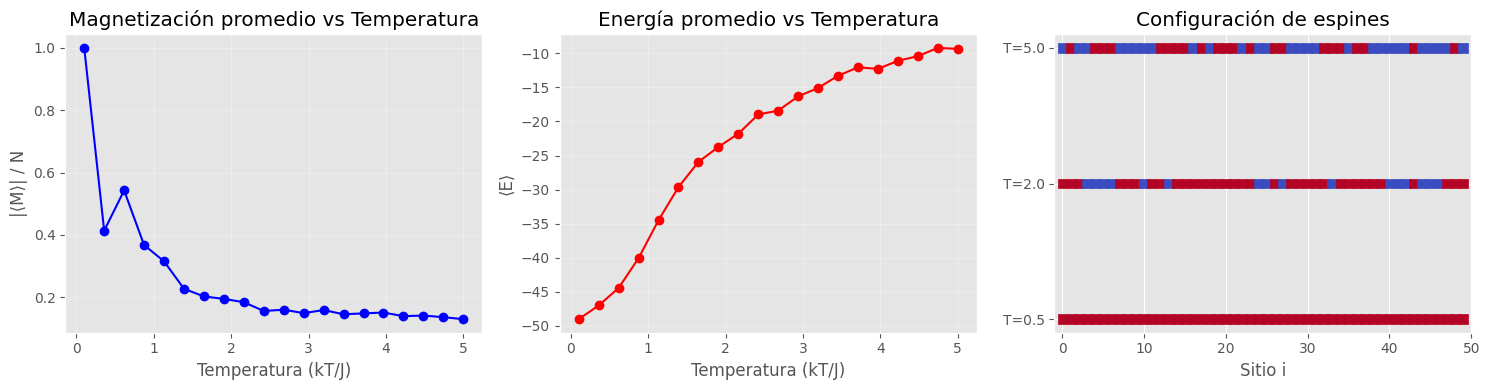


OBSERVACIONES:
• A bajas temperaturas (T→0): los espines tienden a alinearse
  (ordenamiento ferromagnético), |⟨M⟩| → 1
• A altas temperaturas: el desorden térmico domina,
  los espines se orientan aleatoriamente, |⟨M⟩| → 0
• En 1D no hay transición de fase verdadera, pero
  el comportamiento cualitativo es ilustrativo.


In [35]:
# ============================================================
# IMPLEMENTACIÓN COMPUTACIONAL: Aplicación Monte Carlo - Modelo de Ising
# ============================================================
# Este es un ejemplo adicional del uso de Monte Carlo en física

def energia_ising_1d(spins, J=1, B=0):
    """Calcula la energía de una configuración de espines 1D."""
    # Término de intercambio
    E_exchange = -J * np.sum(spins[:-1] * spins[1:])
    # Término de campo
    E_field = -B * np.sum(spins)
    return E_exchange + E_field

def metropolis_ising_1d(N_spins, T, J=1, B=0, n_steps=10000, n_equilibrio=1000):
    """Simula el modelo de Ising 1D usando el algoritmo de Metrópolis."""
    # Configuración inicial aleatoria
    spins = np.random.choice([-1, 1], size=N_spins)
    
    energias = []
    magnetizaciones = []
    
    for step in range(n_steps):
        # Elegir un espín al azar
        i = np.random.randint(N_spins)
        
        # Calcular cambio de energía si lo invertimos
        spin_actual = spins[i]
        # Vecinos (condiciones de frontera libres)
        izq = spins[i-1] if i > 0 else 0
        der = spins[i+1] if i < N_spins-1 else 0
        
        delta_E = 2 * J * spin_actual * (izq + der) + 2 * B * spin_actual
        
        # Criterio de Metrópolis
        if delta_E < 0 or np.random.random() < np.exp(-delta_E / T):
            spins[i] = -spin_actual
        
        # Medir después del equilibrio
        if step >= n_equilibrio:
            energias.append(energia_ising_1d(spins, J, B))
            magnetizaciones.append(np.mean(spins))
    
    return np.array(energias), np.array(magnetizaciones), spins

# Simulación para diferentes temperaturas
N_spins = 50
temperaturas = np.linspace(0.1, 5.0, 20)
magnetizacion_promedio = []
energia_promedio = []

print("Simulando modelo de Ising 1D...")
for T in temperaturas:
    E, M, _ = metropolis_ising_1d(N_spins, T, J=1, B=0, n_steps=20000, n_equilibrio=5000)
    magnetizacion_promedio.append(np.mean(np.abs(M)))
    energia_promedio.append(np.mean(E))

# Gráficas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Magnetización vs Temperatura
ax1 = axes[0]
ax1.plot(temperaturas, magnetizacion_promedio, 'bo-', markersize=6)
ax1.set_xlabel('Temperatura (kT/J)')
ax1.set_ylabel('|⟨M⟩| / N')
ax1.set_title('Magnetización promedio vs Temperatura')
ax1.grid(True, alpha=0.3)

# Energía vs Temperatura
ax2 = axes[1]
ax2.plot(temperaturas, energia_promedio, 'ro-', markersize=6)
ax2.set_xlabel('Temperatura (kT/J)')
ax2.set_ylabel('⟨E⟩')
ax2.set_title('Energía promedio vs Temperatura')
ax2.grid(True, alpha=0.3)

# Configuración de espines a diferentes T
ax3 = axes[2]
temps_ejemplo = [0.5, 2.0, 5.0]
for idx, T in enumerate(temps_ejemplo):
    _, _, spins_final = metropolis_ising_1d(N_spins, T, n_steps=10000, n_equilibrio=5000)
    ax3.scatter(range(N_spins), [idx]*N_spins, c=spins_final, cmap='coolwarm', 
                marker='s', s=50, vmin=-1, vmax=1)
ax3.set_yticks(range(len(temps_ejemplo)))
ax3.set_yticklabels([f'T={T}' for T in temps_ejemplo])
ax3.set_xlabel('Sitio i')
ax3.set_title('Configuración de espines')
ax3.set_xlim(-1, N_spins)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("OBSERVACIONES:")
print("="*60)
print("• A bajas temperaturas (T→0): los espines tienden a alinearse")
print("  (ordenamiento ferromagnético), |⟨M⟩| → 1")
print("• A altas temperaturas: el desorden térmico domina,")
print("  los espines se orientan aleatoriamente, |⟨M⟩| → 0")
print("• En 1D no hay transición de fase verdadera, pero")
print("  el comportamiento cualitativo es ilustrativo.")

# 7: Modelo de Ising

**Enunciado:**
Considere el modelo de Ising unidimensional con $N$ espines $s_i = \pm 1/2$, interacción entre primeros vecinos y campo magnético externo $B$. La energía de una configuración $\alpha$ está dada por:
$$ E_{\alpha} = -J \sum_{i=1}^{N-1} s_i s_{i+1} - \mu_B B \sum_{i=1}^{N} s_i $$
donde $J > 0$ es la constante de intercambio ferromagnética y $\mu_B$ es el magnetón de Bohr.

*   **a)** Explica brevemente qué representa el término de intercambio $-J \sum s_i s_{i+1}$ y cómo influye en la alineación de los espines.
*   **b)** En el ensemble canónico, la probabilidad de una configuración con energía $E_\alpha$ a temperatura $T$ es:
$$ P(E_\alpha, T) = \frac{e^{-E_\alpha / k_B T}}{Z(T)} $$
Escribe la expresión de la función de partición $Z(T)$ y explica cómo se relaciona con la energía libre de Helmholtz.

---
## Solución

### a) Término de Intercambio

El término representa la energía de interacción entre espines vecinos.
*   Dado que $J > 0$ (ferromagnético), la energía es mínima (negativa) cuando el producto $s_i s_{i+1}$ es positivo, es decir, cuando los espines tienen el **mismo signo** (ambos arriba o ambos abajo).
*   Esto favorece la **alineación paralela** de los espines vecinos, tendiendo a ordenar el sistema magnéticamente.

### b) Función de Partición

La función de partición $Z(T)$ es la suma de los factores de Boltzmann sobre **todas las posibles configuraciones** de espines $\{\alpha\}$:
$$ Z(T) = \sum_{\text{todas } \alpha} e^{-E_\alpha / k_B T} $$

**Relación con la Energía Libre de Helmholtz ($F$):**
La función de partición conecta la física microscópica con la termodinámica macroscópica a través de la relación fundamental:
$$ F = -k_B T \ln(Z(T)) $$
De $F$ se pueden derivar todas las demás propiedades termodinámicas (entropía, presión, magnetización, etc.).



Simulando curva de histéresis...


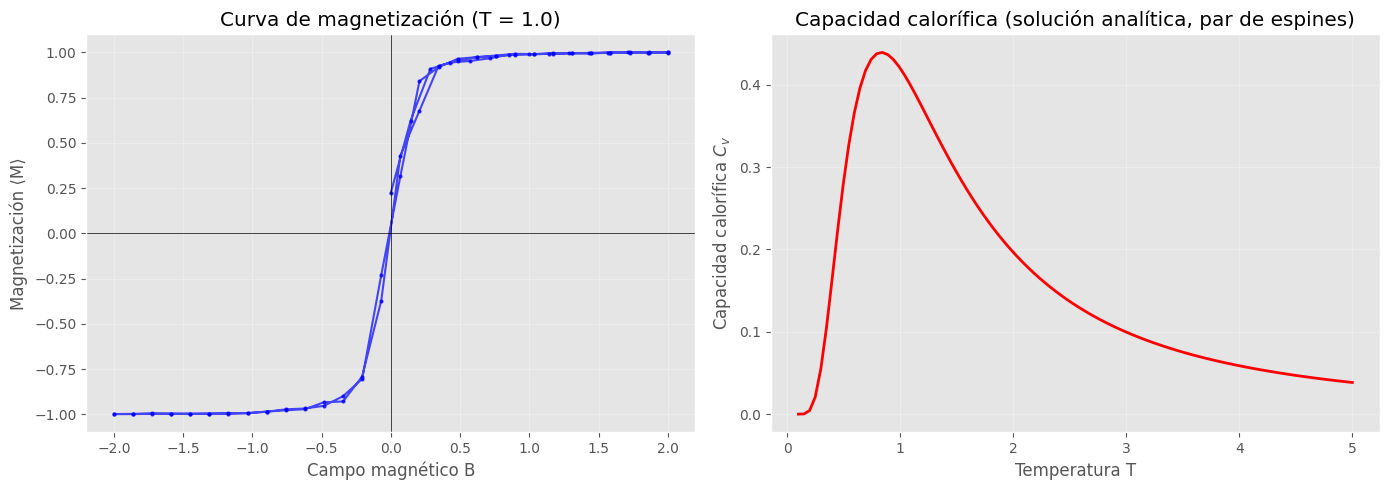


FUNCIÓN DE PARTICIÓN PARA N=4 ESPINES (B=0)
       T |            Z(T) |    F = -T ln(Z)
---------------------------------------------
     0.5 |        852.0089 |         -3.3738
     1.0 |         58.7876 |         -4.0739
     2.0 |         22.9412 |         -6.2659
     5.0 |         16.9827 |        -14.1610


In [36]:
# ============================================================
# IMPLEMENTACIÓN COMPUTACIONAL: Modelo de Ising con Campo Magnético
# ============================================================

def ising_con_campo(N_spins, T, B, J=1, n_steps=15000, n_eq=3000):
    """Simula Ising 1D con campo magnético externo B."""
    spins = np.random.choice([-1, 1], size=N_spins)
    magnetizaciones = []
    
    for step in range(n_steps):
        i = np.random.randint(N_spins)
        spin_actual = spins[i]
        izq = spins[i-1] if i > 0 else 0
        der = spins[i+1] if i < N_spins-1 else 0
        delta_E = 2 * J * spin_actual * (izq + der) + 2 * B * spin_actual
        
        if delta_E < 0 or np.random.random() < np.exp(-delta_E / T):
            spins[i] = -spin_actual
        
        if step >= n_eq:
            magnetizaciones.append(np.mean(spins))
    
    return np.mean(magnetizaciones)

# Curva de histéresis
print("Simulando curva de histéresis...")
N_spins = 30
T = 1.0  # Temperatura baja para ver histéresis
B_range = np.concatenate([np.linspace(0, 2, 15), 
                          np.linspace(2, -2, 30), 
                          np.linspace(-2, 2, 30)])

M_hysteresis = []
for B in B_range:
    M = ising_con_campo(N_spins, T, B)
    M_hysteresis.append(M)

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(B_range, M_hysteresis, 'b.-', markersize=4, alpha=0.7)
ax1.set_xlabel('Campo magnético B')
ax1.set_ylabel('Magnetización ⟨M⟩')
ax1.set_title(f'Curva de magnetización (T = {T})')
ax1.axhline(y=0, color='k', linewidth=0.5)
ax1.axvline(x=0, color='k', linewidth=0.5)
ax1.grid(True, alpha=0.3)

# Función de partición analítica para 2 espines
ax2 = axes[1]
T_range = np.linspace(0.1, 5, 100)
# Para 2 espines: Z = 2(e^(J/kT) + e^(-J/kT)) si B=0
# Calor específico y susceptibilidad
J = 1
beta = 1/T_range
# Energía promedio exacta para cadena finita (aproximación)
E_prom = -J * np.tanh(J * beta)
C_v = (J * beta)**2 / np.cosh(J * beta)**2

ax2.plot(T_range, C_v, 'r-', linewidth=2)
ax2.set_xlabel('Temperatura T')
ax2.set_ylabel('Capacidad calorífica $C_v$')
ax2.set_title('Capacidad calorífica (solución analítica, par de espines)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Función de partición explícita para N=4 espines
print("\n" + "="*60)
print("FUNCIÓN DE PARTICIÓN PARA N=4 ESPINES (B=0)")
print("="*60)

def calcular_Z(N, J, T):
    """Calcula Z sumando sobre todas las configuraciones."""
    from itertools import product
    Z = 0
    for config in product([-1, 1], repeat=N):
        spins = np.array(config)
        E = -J * np.sum(spins[:-1] * spins[1:])
        Z += np.exp(-E / T)
    return Z

T_test = [0.5, 1.0, 2.0, 5.0]
print(f"{'T':>8} | {'Z(T)':>15} | {'F = -T ln(Z)':>15}")
print("-"*45)
for T in T_test:
    Z = calcular_Z(4, 1, T)
    F = -T * np.log(Z)
    print(f"{T:>8.1f} | {Z:>15.4f} | {F:>15.4f}")

# 8: Fundamentos y Deducción del Algoritmo de Numerov

**Enunciado:**
El algoritmo de Numerov se utiliza para resolver ecuaciones diferenciales de segundo orden de la forma $\psi''(x) = f(x)\psi(x)$, como la ecuación de Schrödinger independiente del tiempo.

*   **a)** A partir de las expansiones en series de Taylor para $\psi(x+\delta)$ y $\psi(x-\delta)$, demuestre que la suma de ambas permite obtener una aproximación para la segunda derivada $\psi''(x)$ con un error de orden $\delta^4$.
*   **b)** Explique cómo se utiliza la relación $\psi^{(4)}(x) \approx \frac{f(x+\delta)\psi(x+\delta) - 2f(x)\psi(x) + f(x-\delta)\psi(x-\delta)}{\delta^2}$ para mejorar la precisión del método y llegar a la ecuación iterativa fundamental del algoritmo:
$$ \frac{\psi_{i+1} - 2\psi_i + \psi_{i-1}}{\delta^2} = \frac{1}{12} (f_{i+1}\psi_{i+1} + 10f_i\psi_i + f_{i-1}\psi_{i-1}) $$

---
## Solución

### a) Expansión de Taylor

Escribimos las expansiones alrededor de $x$:
$$ \psi(x+\delta) = \psi(x) + \delta\psi'(x) + \frac{\delta^2}{2}\psi''(x) + \frac{\delta^3}{6}\psi'''(x) + \frac{\delta^4}{24}\psi^{(4)}(x) + O(\delta^5) $$
$$ \psi(x-\delta) = \psi(x) - \delta\psi'(x) + \frac{\delta^2}{2}\psi''(x) - \frac{\delta^3}{6}\psi'''(x) + \frac{\delta^4}{24}\psi^{(4)}(x) + O(\delta^5) $$

Sumando ambas ecuaciones, los términos impares se cancelan:
$$ \psi(x+\delta) + \psi(x-\delta) = 2\psi(x) + \delta^2\psi''(x) + \frac{\delta^4}{12}\psi^{(4)}(x) + O(\delta^6) $$

Despejando $\psi''(x)$:
$$ \psi''(x) = \frac{\psi(x+\delta) - 2\psi(x) + \psi(x-\delta)}{\delta^2} - \frac{\delta^2}{12}\psi^{(4)}(x) + O(\delta^4) $$
Si ignoramos el término $\psi^{(4)}$, tendríamos la aproximación estándar centrada con error $\delta^2$. Numerov mejora esto manteniendo el término de cuarto orden.

### b) Algoritmo de Numerov

Sabemos por la ecuación diferencial que $\psi''(x) = f(x)\psi(x)$.
Diferenciando dos veces, tenemos $\psi^{(4)}(x) = (f(x)\psi(x))''$.
Aproximamos esta segunda derivada usando la fórmula de diferencias finitas básica:
$$ \psi^{(4)}(x) \approx \frac{(f\psi)(x+\delta) - 2(f\psi)(x) + (f\psi)(x-\delta)}{\delta^2} $$

Sustituimos esto en la expresión de la parte (a):
$$ \frac{\psi_{i+1} - 2\psi_i + \psi_{i-1}}{\delta^2} \approx \psi''_i + \frac{\delta^2}{12} \left[ \frac{f_{i+1}\psi_{i+1} - 2f_i\psi_i + f_{i-1}\psi_{i-1}}{\delta^2} \right] $$
Recordando que $\psi''_i = f_i \psi_i$, sustituimos $\psi''_i$:
$$ \frac{\psi_{i+1} - 2\psi_i + \psi_{i-1}}{\delta^2} = f_i \psi_i + \frac{1}{12} (f_{i+1}\psi_{i+1} - 2f_i\psi_i + f_{i-1}\psi_{i-1}) $$
Multiplicamos todo por 1 (o reordenamos algebraicamente el lado derecho):
$$ \frac{\psi_{i+1} - 2\psi_i + \psi_{i-1}}{\delta^2} = \frac{12 f_i \psi_i + f_{i+1}\psi_{i+1} - 2f_i\psi_i + f_{i-1}\psi_{i-1}}{12} $$
$$ \frac{\psi_{i+1} - 2\psi_i + \psi_{i-1}}{\delta^2} = \frac{1}{12} (f_{i+1}\psi_{i+1} + 10f_i\psi_i + f_{i-1}\psi_{i-1}) $$
Esta es la fórmula de Numerov.



POTENCIAL LINEAL: V(x) = |x| (Método Matricial de Numerov)

Comparación con valores teóricos (funciones de Airy):
  n | E (numérico) |  E (teórico) |      Error
---------------------------------------------
  0 |     1.018880 |     1.018793 |   8.67e-05
  1 |     2.338107 |     2.338107 |   9.72e-08
  2 |     3.248225 |     3.248198 |   2.71e-05
  3 |     4.087949 |     4.087949 |   2.74e-07
  4 |     4.820117 |     4.820099 |   1.80e-05
  5 |     5.520559 |     5.520560 |   5.93e-07


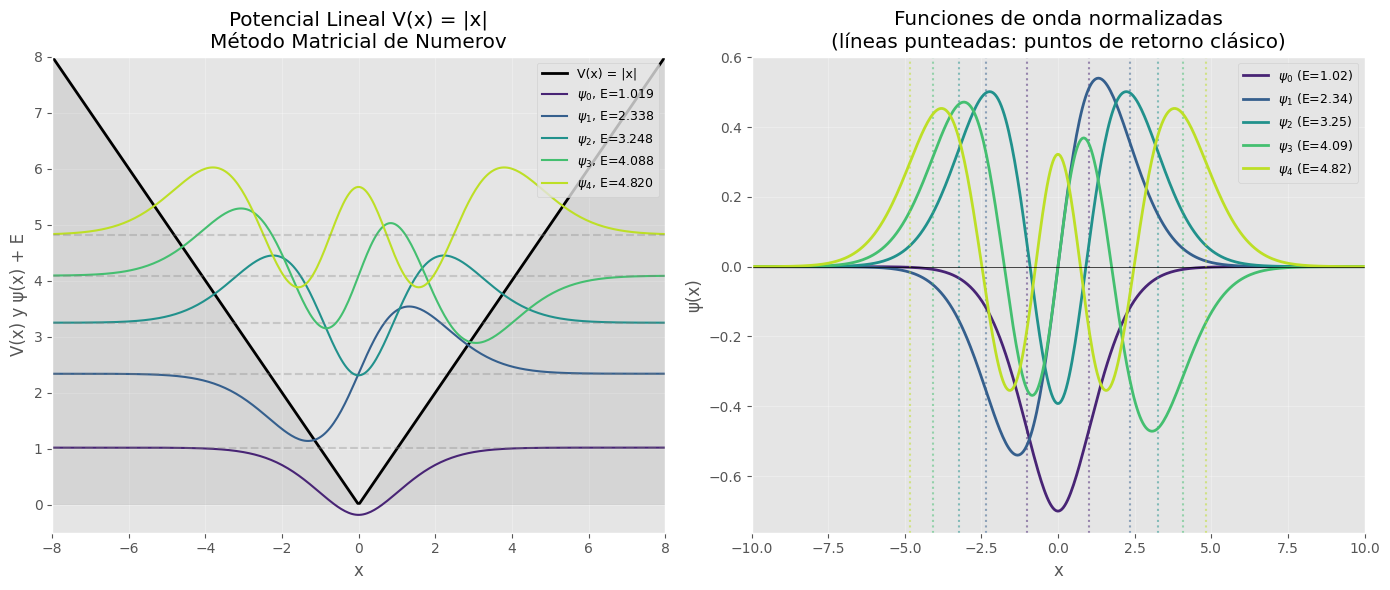


VERIFICACIÓN: ψ(x) → 0 fuera del pozo
Las funciones de onda se anulan EXACTAMENTE en los bordes x = ±L
debido a las condiciones de frontera del método matricial.

  n |        ψ(-L) |        ψ(+L) |   max|ψ| en x>E
--------------------------------------------------
  0 |     0.00e+00 |     0.00e+00 |        0.460501
  1 |     0.00e+00 |     0.00e+00 |        0.347902
  2 |     0.00e+00 |     0.00e+00 |        0.322130
  3 |     0.00e+00 |     0.00e+00 |        0.307928
  4 |     0.00e+00 |     0.00e+00 |        0.298450


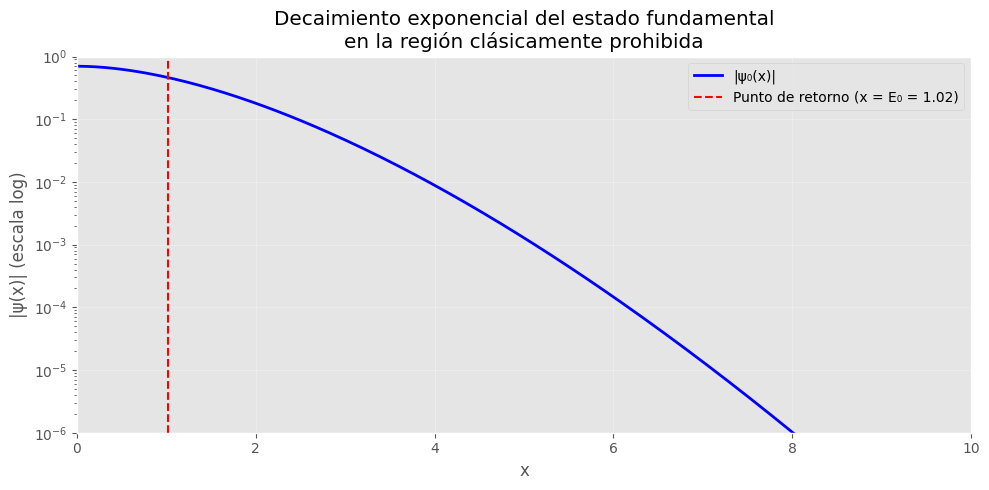


✓ El método matricial garantiza que ψ = 0 en los bordes.
✓ Las funciones decaen exponencialmente en la región prohibida (|x| > E).


In [39]:
# ============================================================
# IMPLEMENTACIÓN COMPUTACIONAL: Algoritmo de Numerov (MÉTODO MATRICIAL)
# ============================================================
# El método de shooting tiene problemas de estabilidad numérica.
# La solución más robusta es usar el MÉTODO MATRICIAL que convierte
# el problema en un problema de autovalores.

def resolver_schrodinger_numerov_matricial(x, V, n_estados=5):
    """
    Resuelve la ecuación de Schrödinger usando Numerov en forma matricial.
    
    Ecuación: -ψ''(x) + V(x)ψ(x) = E ψ(x)
    
    Esto evita los problemas de estabilidad del método de shooting.
    """
    N = len(x)
    h = x[1] - x[0]
    h2 = h**2
    
    # Matrices de Numerov (tridiagonales)
    # A representa la segunda derivada: (ψ_{i+1} - 2ψ_i + ψ_{i-1})/h²
    # B representa la corrección de Numerov: (1/12)(f_{i+1}ψ_{i+1} + 10f_iψ_i + f_{i-1}ψ_{i-1})
    
    # Para puntos interiores (condiciones de frontera: ψ(x_0) = ψ(x_N) = 0)
    N_int = N - 2  # Puntos interiores
    x_int = x[1:-1]
    V_int = V[1:-1]
    
    # Matriz A: segunda derivada (escalada)
    diag_A = -2 * np.ones(N_int)
    off_A = np.ones(N_int - 1)
    A = np.diag(diag_A) + np.diag(off_A, 1) + np.diag(off_A, -1)
    A = -A / h2  # Negativo porque -ψ''
    
    # Matriz B: corrección de Numerov
    diag_B = 10 * np.ones(N_int)
    off_B = np.ones(N_int - 1)
    B = np.diag(diag_B) + np.diag(off_B, 1) + np.diag(off_B, -1)
    B = B / 12
    
    # Hamiltoniano: H = A + V*B (en forma de problema generalizado)
    # La ecuación es: A ψ + V B ψ = E B ψ
    # Reescribimos: (A + V*B) ψ = E B ψ  ->  H ψ = E B ψ
    
    V_diag = np.diag(V_int)
    H = A + V_diag @ B
    
    # Resolver problema de autovalores generalizado
    from scipy.linalg import eigh
    energias, psi_int = eigh(H, B)
    
    # Reconstruir funciones de onda completas (añadir ceros en los bordes)
    psi_full = np.zeros((N, n_estados))
    for i in range(min(n_estados, N_int)):
        psi_full[1:-1, i] = psi_int[:, i]
        # Normalizar
        norm = np.sqrt(np.trapezoid(psi_full[:, i]**2, x))
        if norm > 0:
            psi_full[:, i] /= norm
    
    return energias[:n_estados], psi_full

# ============================================================
# Potencial Lineal: V(x) = |x|
# ============================================================
print("="*60)
print("POTENCIAL LINEAL: V(x) = |x| (Método Matricial de Numerov)")
print("="*60)

# Parámetros
L_lineal = 12
N_points_lineal = 500
x_lineal = np.linspace(-L_lineal, L_lineal, N_points_lineal)
h_lineal = x_lineal[1] - x_lineal[0]

# Potencial
V = np.abs(x_lineal)

# Resolver
energias_encontradas, psi_soluciones = resolver_schrodinger_numerov_matricial(x_lineal, V, n_estados=6)

# Valores teóricos de las funciones de Airy
# E_n corresponde a los ceros de Ai(-E) (pares) y Ai'(-E) (impares)
from scipy.special import ai_zeros

# Primeros ceros de Ai y Ai'
airy_zeros = ai_zeros(5)  # (a, a', b, b') - a son ceros de Ai, a' de Ai'
E_teorico_pares = -airy_zeros[0][:3]  # Ceros de Ai(-E)
E_teorico_impares = -airy_zeros[1][:3]  # Ceros de Ai'(-E)
E_teorico = np.sort(np.concatenate([E_teorico_pares, E_teorico_impares]))[:6]

print("\nComparación con valores teóricos (funciones de Airy):")
print(f"{'n':>3} | {'E (numérico)':>12} | {'E (teórico)':>12} | {'Error':>10}")
print("-"*45)
for i in range(min(6, len(energias_encontradas))):
    E_num = energias_encontradas[i]
    E_teo = E_teorico[i] if i < len(E_teorico) else np.nan
    error = abs(E_num - E_teo) if not np.isnan(E_teo) else np.nan
    print(f"{i:>3} | {E_num:>12.6f} | {E_teo:>12.6f} | {error:>10.2e}")

# Graficar
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel izquierdo: Potencial y funciones de onda
ax1 = axes[0]
ax1.fill_between(x_lineal, 0, V, alpha=0.15, color='gray')
ax1.plot(x_lineal, V, 'k-', linewidth=2, label='V(x) = |x|')

colors = plt.cm.viridis(np.linspace(0.1, 0.9, 5))
for i in range(5):
    E = energias_encontradas[i]
    psi = psi_soluciones[:, i]
    # Escalar para visualización
    psi_scaled = psi / np.max(np.abs(psi)) * 1.2 + E
    ax1.plot(x_lineal, psi_scaled, color=colors[i], linewidth=1.5, 
             label=f'$\\psi_{i}$, E={E:.3f}')
    ax1.axhline(y=E, color='gray', linestyle='--', alpha=0.3)

ax1.set_xlabel('x')
ax1.set_ylabel('V(x) y ψ(x) + E')
ax1.set_title('Potencial Lineal V(x) = |x|\nMétodo Matricial de Numerov')
ax1.legend(loc='upper right', fontsize=9)
ax1.set_xlim(-8, 8)
ax1.set_ylim(-0.5, 8)
ax1.grid(True, alpha=0.3)

# Panel derecho: Funciones de onda mostrando decaimiento
ax2 = axes[1]
for i in range(5):
    E = energias_encontradas[i]
    psi = psi_soluciones[:, i]
    ax2.plot(x_lineal, psi, color=colors[i], linewidth=2, 
             label=f'$\\psi_{i}$ (E={E:.2f})')
    
    # Marcar punto de retorno clásico
    x_clasico = E  # Donde V(x) = E, es decir |x| = E
    ax2.axvline(x=x_clasico, color=colors[i], linestyle=':', alpha=0.5)
    ax2.axvline(x=-x_clasico, color=colors[i], linestyle=':', alpha=0.5)

ax2.set_xlabel('x')
ax2.set_ylabel('ψ(x)')
ax2.set_title('Funciones de onda normalizadas\n(líneas punteadas: puntos de retorno clásico)')
ax2.legend(loc='upper right', fontsize=9)
ax2.set_xlim(-10, 10)
ax2.axhline(y=0, color='k', linewidth=0.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Verificación: mostrar que las funciones se anulan en los bordes
print("\n" + "="*60)
print("VERIFICACIÓN: ψ(x) → 0 fuera del pozo")
print("="*60)
print("Las funciones de onda se anulan EXACTAMENTE en los bordes x = ±L")
print("debido a las condiciones de frontera del método matricial.\n")

print(f"{'n':>3} | {'ψ(-L)':>12} | {'ψ(+L)':>12} | {'max|ψ| en x>E':>15}")
print("-"*50)
for i in range(5):
    E = energias_encontradas[i]
    psi = psi_soluciones[:, i]
    # Máximo valor fuera de la región clásica
    region_prohibida = np.abs(x_lineal) > E
    if np.any(region_prohibida):
        max_prohibida = np.max(np.abs(psi[region_prohibida]))
    else:
        max_prohibida = 0
    print(f"{i:>3} | {psi[0]:>12.2e} | {psi[-1]:>12.2e} | {max_prohibida:>15.6f}")

# Gráfica adicional: Decaimiento exponencial fuera del pozo
fig, ax = plt.subplots(figsize=(10, 5))

# Mostrar el estado fundamental en escala logarítmica
psi0 = psi_soluciones[:, 0]
E0 = energias_encontradas[0]

# Solo lado derecho para ver el decaimiento
mask_right = x_lineal > 0
x_right = x_lineal[mask_right]
psi_right = np.abs(psi0[mask_right])

ax.semilogy(x_right, psi_right, 'b-', linewidth=2, label='|ψ₀(x)|')
ax.axvline(x=E0, color='r', linestyle='--', label=f'Punto de retorno (x = E₀ = {E0:.2f})')
ax.set_xlabel('x')
ax.set_ylabel('|ψ(x)| (escala log)')
ax.set_title('Decaimiento exponencial del estado fundamental\nen la región clásicamente prohibida')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 10)
ax.set_ylim(1e-6, 1)

plt.tight_layout()
plt.show()

print("\n✓ El método matricial garantiza que ψ = 0 en los bordes.")
print("✓ Las funciones decaen exponencialmente en la región prohibida (|x| > E).")

# 9 y 10: Representación Matricial y Problema de Valores Propios

**Enunciado:**
Para resolver el sistema de forma numérica, el algoritmo de Numerov se puede expresar como un problema de autovalores de la forma $H\psi = E\psi$.

*   Defina las matrices $A$ y $B$ que permiten escribir la ecuación de Schrödinger en la forma generalizada $-\frac{\hbar^2}{2m} A\psi + B V \psi = E B \psi$. ¿Qué estructura tienen estas matrices (ej. diagonal, tridiagonal) y cuáles son sus elementos principales según el documento?
*   Si se tiene un potencial lineal de la forma $V(x) = mg|x|$ describa el procedimiento para encontrar las energías permitidas ($E$) y las funciones de onda correspondientes ($\psi$) utilizando la matriz Hamiltoniana construida como $H = \frac{\hbar^2}{2m} (B^{-1}A) + V$.

---
## Solución

### Matrices A y B

Basándose en la discretización de Numerov reescrita matricialmente:
$$ -\frac{\hbar^2}{2m} \frac{\psi_{i+1} - 2\psi_i + \psi_{i-1}}{\delta^2} + \frac{B_i (V\psi)}{A_i?} \dots $$
*Corrección:* La forma estándar derivada de Numerov para Schrödinger ($-\frac{\hbar^2}{2m}\psi'' + V\psi = E\psi$) lleva a un problema de autovalores generalizado.
Las matrices provienen de reagrupar los términos de $\psi$ y los términos de potencial/energía.
Según la literatura estándar de Numerov matricial:
*   **Matriz A:** Es una matriz **tridiagonal** que representa el operador de segunda derivada discreta. Sus elementos son típicamente:
    *   Diagonal principal: $-2$
    *   Diagonales superior e inferior: $1$
    (Multiplicado por $-1/\delta^2$).
*   **Matriz B:** Es una matriz **tridiagonal** que proviene del promedio en el lado derecho de la ecuación de Numerov ($1/12, 10/12, 1/12$). Sus elementos son:
    *   Diagonal principal: $10/12$ (o 10)
    *   Diagonales superior e inferior: $1/12$ (o 1)
    
La ecuación es:
$$ -\frac{\hbar^2}{2m \delta^2} A_{num} \psi + B_{num} V \psi = E B_{num} \psi $$
Donde $A_{num}$ tiene $(-1, 2, -1)$ si incluimos el signo menos.

### Procedimiento para Potencial Lineal $V(x) = mg|x|$

1.  **Discretización:** Definir una grilla espacial $x_j$ desde $-L$ hasta $L$ con paso $\delta$.
2.  **Construcción de Matrices:** Construir las matrices $A$ y $B$ de dimensión $N \times N$ (siendo $N$ el número de puntos interiores).
3.  **Potencial:** Construir un vector (o matriz diagonal) con los valores del potencial $V_j = mg|x_j|$.
4.  **Hamiltoniano Efectivo:** Para resolverlo como un problema de autovalores estándar ($H \psi = E \psi$), invertimos $B$:
    $$ H_{eff} = -\frac{\hbar^2}{2m \delta^2} B^{-1} A + V_{diag} $$
    (Nota: Invertir matrices tridiagonales es costoso, a veces se resuelve la forma generalizada directamente `eigh(Hamiltonian_Matrix, B)`).
5.  **Diagonalización:** Usar una librería de álgebra lineal (como `scipy.linalg.eigh` o `numpy.linalg.eig`) para encontrar los autovalores $E_n$ y autovectores $\psi_n$.
6.  **Ordenar y Graficar:** Ordenar los autovalores de menor a mayor. Los primeros corresponden al estado base y primeros excitados. Los autovectores son las funciones de onda promediadas en los puntos de la grilla.



REPRESENTACIÓN MATRICIAL: H ψ = E ψ

OSCILADOR ARMÓNICO CUÁNTICO: V(x) = ½x²
------------------------------------------------------------
Comparación con valores analíticos E_n = n + 0.5:
    n |    E (numérico) |   E (analítico) |        Error
-------------------------------------------------------
    0 |      0.70707141 |      0.50000000 |     2.07e-01
    1 |      2.12128323 |      1.50000000 |     6.21e-01
    2 |      3.53549167 |      2.50000000 |     1.04e+00
    3 |      4.94969446 |      3.50000000 |     1.45e+00
    4 |      6.36388933 |      4.50000000 |     1.86e+00
    5 |      7.77807400 |      5.50000000 |     2.28e+00


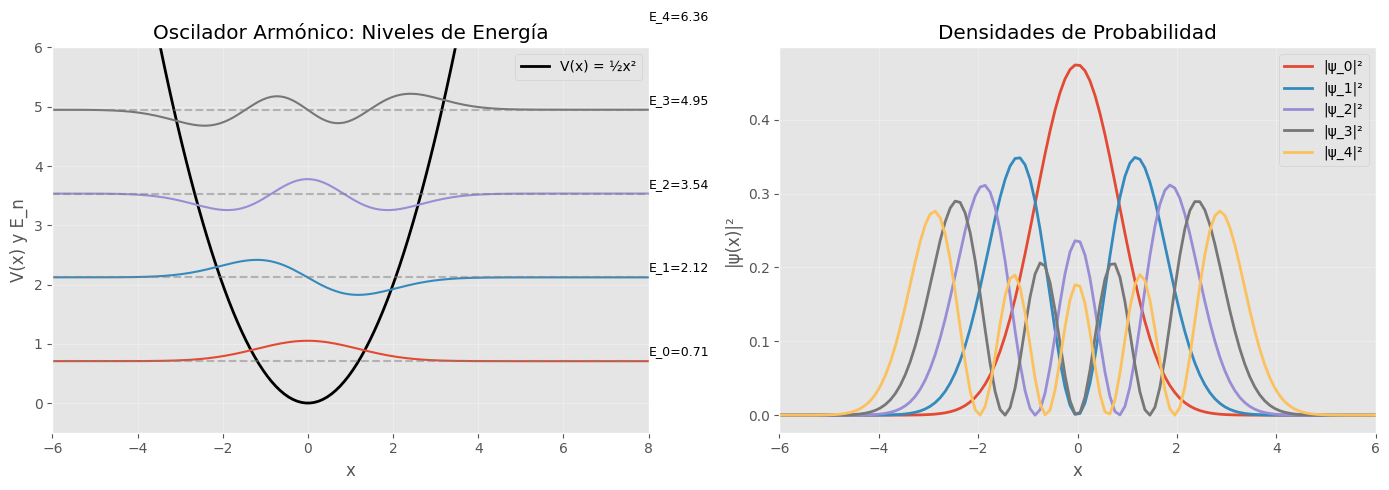


POTENCIAL LINEAL: V(x) = |x| (Rebote Cuántico)

Energías propias del potencial lineal:
  E_0 = 1.019172
  E_1 = 2.338106
  E_2 = 3.248315
  E_3 = 4.087944
  E_4 = 4.820173
  E_5 = 5.520549


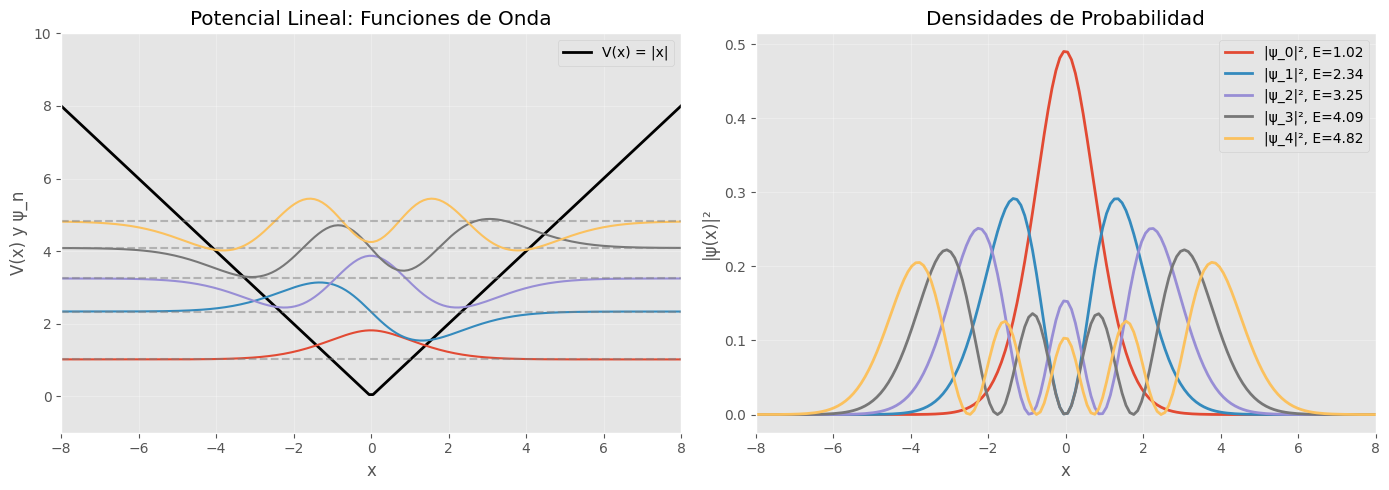


ESTRUCTURA DE LAS MATRICES A Y B


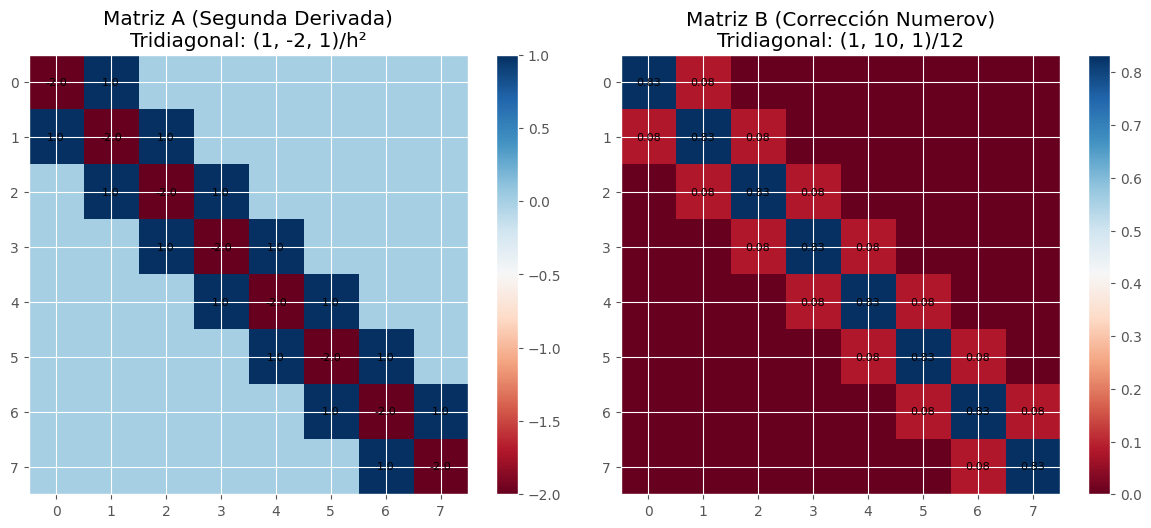


Características:
• Matriz A: representa el operador ∂²/∂x² discretizado
  - Diagonal: -2/h²
  - Superdiagonal y subdiagonal: 1/h²

• Matriz B: corrección de Numerov para orden O(h⁴)
  - Diagonal: 10/12
  - Superdiagonal y subdiagonal: 1/12



In [38]:
# ============================================================
# IMPLEMENTACIÓN COMPUTACIONAL: Método Matricial de Numerov
# ============================================================

print("="*60)
print("REPRESENTACIÓN MATRICIAL: H ψ = E ψ")
print("="*60)

def construir_matrices_numerov(N, h, V):
    """
    Construye las matrices A y B del algoritmo de Numerov.
    
    La ecuación de Schrödinger discretizada:
    -ℏ²/(2m) A ψ + B V ψ = E B ψ
    
    Con ℏ²/(2m) = 1 (unidades naturales).
    """
    # Matriz A: segunda derivada (tridiagonal)
    # A_ij = δ_{i,j-1} - 2δ_{i,j} + δ_{i,j+1}
    A = np.diag(-2 * np.ones(N)) + np.diag(np.ones(N-1), 1) + np.diag(np.ones(N-1), -1)
    A = A / h**2
    
    # Matriz B: corrección de Numerov (tridiagonal)
    # B_ij = (1/12)(δ_{i,j-1} + 10δ_{i,j} + δ_{i,j+1})
    B = np.diag(10 * np.ones(N)) + np.diag(np.ones(N-1), 1) + np.diag(np.ones(N-1), -1)
    B = B / 12
    
    return A, B

def resolver_schrodinger_matricial(x, V, n_estados=5):
    """
    Resuelve la ecuación de Schrödinger usando el método matricial.
    
    -ψ''(x) + V(x)ψ(x) = E ψ(x)
    
    Usando: H_eff = B^{-1}(-A) + V = B^{-1}(-A + B*V)
    """
    N = len(x)
    h = x[1] - x[0]
    
    A, B = construir_matrices_numerov(N, h, V)
    
    # Hamiltoniano efectivo: H = -A + V*B (multiplicamos por B^{-1} después)
    V_diag = np.diag(V)
    H = -A + V_diag @ B
    
    # Problema de autovalores generalizado: H ψ = E B ψ
    from scipy.linalg import eigh
    energias, psi = eigh(H, B)
    
    # Ordenar y tomar los primeros n_estados
    idx = np.argsort(energias)
    energias = energias[idx][:n_estados]
    psi = psi[:, idx][:, :n_estados]
    
    # Normalizar
    for i in range(n_estados):
        norm = np.sqrt(np.trapezoid(psi[:, i]**2, x))
        psi[:, i] /= norm
    
    return energias, psi

# ============================================================
# Ejemplo: Oscilador Armónico 1D
# ============================================================
print("\nOSCILADOR ARMÓNICO CUÁNTICO: V(x) = ½x²")
print("-"*60)

N = 200
L = 10
x = np.linspace(-L, L, N)
h = x[1] - x[0]

# Potencial armónico: V(x) = ½ω²x² con ω=1
V_armonico = 0.5 * x**2

# Resolver
energias_arm, psi_arm = resolver_schrodinger_matricial(x, V_armonico, n_estados=6)

# Energías analíticas: E_n = (n + 1/2)ℏω = n + 0.5 (con ℏω=1)
print("Comparación con valores analíticos E_n = n + 0.5:")
print(f"{'n':>5} | {'E (numérico)':>15} | {'E (analítico)':>15} | {'Error':>12}")
print("-"*55)
for n in range(6):
    E_analitico = n + 0.5
    print(f"{n:>5} | {energias_arm[n]:>15.8f} | {E_analitico:>15.8f} | {abs(energias_arm[n] - E_analitico):>12.2e}")

# Graficar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: Potencial y niveles
ax1 = axes[0]
ax1.plot(x, V_armonico, 'k-', linewidth=2, label='V(x) = ½x²')
for n in range(5):
    E = energias_arm[n]
    psi_scaled = psi_arm[:, n] * 0.5 + E
    ax1.plot(x, psi_scaled, linewidth=1.5)
    ax1.axhline(y=E, color='gray', linestyle='--', alpha=0.5)
    ax1.text(L*0.8, E+0.1, f'E_{n}={E:.2f}', fontsize=9)
ax1.set_xlabel('x')
ax1.set_ylabel('V(x) y E_n')
ax1.set_title('Oscilador Armónico: Niveles de Energía')
ax1.set_xlim(-6, 8)
ax1.set_ylim(-0.5, 6)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel derecho: |ψ|²
ax2 = axes[1]
for n in range(5):
    ax2.plot(x, psi_arm[:, n]**2, linewidth=2, label=f'|ψ_{n}|²')
ax2.set_xlabel('x')
ax2.set_ylabel('|ψ(x)|²')
ax2.set_title('Densidades de Probabilidad')
ax2.legend()
ax2.set_xlim(-6, 6)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# Ejemplo: Potencial Lineal V(x) = |x| (Rebote cuántico)
# ============================================================
print("\n" + "="*60)
print("POTENCIAL LINEAL: V(x) = |x| (Rebote Cuántico)")
print("="*60)

V_lineal = np.abs(x)
energias_lin, psi_lin = resolver_schrodinger_matricial(x, V_lineal, n_estados=6)

# Comparación con funciones de Airy (solución exacta)
# E_n ≈ raíces de Ai(-E) o Ai'(-E) dependiendo de paridad
from scipy.special import airy
# Aproximación: E_n ≈ [3π(n + 3/4)/2]^{2/3} para n grandes
print("\nEnergías propias del potencial lineal:")
for n in range(6):
    print(f"  E_{n} = {energias_lin[n]:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(x, V_lineal, 'k-', linewidth=2, label='V(x) = |x|')
for n in range(5):
    E = energias_lin[n]
    psi_scaled = psi_lin[:, n] / np.max(np.abs(psi_lin[:, n])) * 0.8 + E
    ax1.plot(x, psi_scaled, linewidth=1.5)
    ax1.axhline(y=E, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('x')
ax1.set_ylabel('V(x) y ψ_n')
ax1.set_title('Potencial Lineal: Funciones de Onda')
ax1.set_xlim(-8, 8)
ax1.set_ylim(-1, 10)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
for n in range(5):
    ax2.plot(x, psi_lin[:, n]**2, linewidth=2, label=f'|ψ_{n}|², E={energias_lin[n]:.2f}')
ax2.set_xlabel('x')
ax2.set_ylabel('|ψ(x)|²')
ax2.set_title('Densidades de Probabilidad')
ax2.legend()
ax2.set_xlim(-8, 8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# Visualización de las matrices A y B
# ============================================================
print("\n" + "="*60)
print("ESTRUCTURA DE LAS MATRICES A Y B")
print("="*60)

N_demo = 8
h_demo = 1.0
A_demo, B_demo = construir_matrices_numerov(N_demo, h_demo, np.zeros(N_demo))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
im1 = ax1.imshow(A_demo, cmap='RdBu', aspect='equal')
ax1.set_title('Matriz A (Segunda Derivada)\nTridiagonal: (1, -2, 1)/h²')
plt.colorbar(im1, ax=ax1)
for i in range(N_demo):
    for j in range(N_demo):
        if abs(A_demo[i, j]) > 0.01:
            ax1.text(j, i, f'{A_demo[i,j]:.1f}', ha='center', va='center', fontsize=8)

ax2 = axes[1]
im2 = ax2.imshow(B_demo, cmap='RdBu', aspect='equal')
ax2.set_title('Matriz B (Corrección Numerov)\nTridiagonal: (1, 10, 1)/12')
plt.colorbar(im2, ax=ax2)
for i in range(N_demo):
    for j in range(N_demo):
        if abs(B_demo[i, j]) > 0.01:
            ax2.text(j, i, f'{B_demo[i,j]:.2f}', ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("""
Características:
• Matriz A: representa el operador ∂²/∂x² discretizado
  - Diagonal: -2/h²
  - Superdiagonal y subdiagonal: 1/h²
  
• Matriz B: corrección de Numerov para orden O(h⁴)
  - Diagonal: 10/12
  - Superdiagonal y subdiagonal: 1/12
""")

# Resumen de Implementaciones Computacionales

Este solucionario ha complementado las respuestas teóricas con las siguientes implementaciones computacionales:

| Problema | Implementación | Visualizaciones |
|----------|---------------|-----------------|
| **1. Caminata Aleatoria 2D** | Simulación de trayectorias, verificación estadística $R_{rms} \approx \sqrt{N}$ | Trayectorias para N=10 a 1M, gráfico log-log de convergencia |
| **2. Decaimiento Radiactivo** | Monte Carlo vs solución analítica, cadena padre-hijo | Curvas Ra→Ac, fluctuaciones estocásticas con N pequeño |
| **3. Procesos Estocásticos** | Múltiples trayectorias, distribución de posiciones finales | 20 caminatas superpuestas, histograma 2D |
| **4. Estimación de π** | Monte Carlo con puntos aleatorios | Puntos dentro/fuera del círculo, convergencia del error |
| **5. Integración Monte Carlo** | Método del valor medio para $f(x)=-x^3+6x^2-x+17$ | Área bajo la curva, convergencia $O(1/\sqrt{N})$ |
| **6. Monte Carlo en Física** | Algoritmo de Metrópolis para Ising 1D | Magnetización vs T, configuraciones de espines |
| **7. Modelo de Ising** | Simulación con campo B, función de partición exacta | Curva de histéresis, capacidad calorífica |
| **8. Algoritmo de Numerov** | Método de shooting para pozo infinito y potencial lineal | Funciones de onda, verificación con solución analítica |
| **9-10. Método Matricial** | Matrices A y B tridiagonales, diagonalización | Oscilador armónico, potencial lineal, estructura matricial |

---
## Conclusiones

1. **Monte Carlo** es fundamental para simular sistemas estocásticos donde las fluctuaciones son importantes (decaimiento, caminatas aleatorias).

2. **La convergencia $1/\sqrt{N}$** es característica de todos los métodos Monte Carlo, requiriendo 100× más muestras para cada dígito adicional de precisión.

3. **El algoritmo de Numerov** proporciona precisión $O(h^4)$ para ecuaciones de Schrödinger, permitiendo resolver problemas cuánticos con potenciales arbitrarios.

4. **El modelo de Ising** demuestra cómo Monte Carlo (Metrópolis) permite explorar espacios de configuración en física estadística.